## Cell 1 — Setup: logging, figure style, Google Drive

In [ ]:
# ============================================================================
# CELL 1 — SETUP: LOGGING, PUBLICATION-QUALITY FIGURE STYLE, GOOGLE DRIVE
# Run once at the start of the session. All later cells reuse DRIVE_FOLDER,
# logger, and the matplotlib rcParams set here.
# ============================================================================
from google.colab import drive
drive.mount('/content/drive')

import os
import sys
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DRIVE_FOLDER = "/content/drive/MyDrive/Zenodo_Mekong_Data"

# --- Logging ---
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    handlers=[logging.StreamHandler(sys.stdout)],
)
logger = logging.getLogger(__name__)

# --- Publication-quality matplotlib style, reused by every figure in this notebook ---
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Arial", "Helvetica"],
    "font.size": 11,
    "axes.titlesize": 12.5,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
    "savefig.bbox": "tight",
})

# Consistent color palette used across all figures in this notebook
COLOR_PRIMARY = "#1b6ca8"   # blue  — the model / main class / precision
COLOR_ACCENT = "#d6604d"    # red   — contrast class / recall
COLOR_NEUTRAL = "#4d4d4d"   # gray  — reference lines / F1 / secondary series

logger.info(f"Setup complete. DRIVE_FOLDER = {DRIVE_FOLDER}")
logger.info(f"Files currently in DRIVE_FOLDER: {len(os.listdir(DRIVE_FOLDER))}")


Mounted at /content/drive


## Cell 2 — Task 19.1-19.2: Class balance & scale_pos_weight

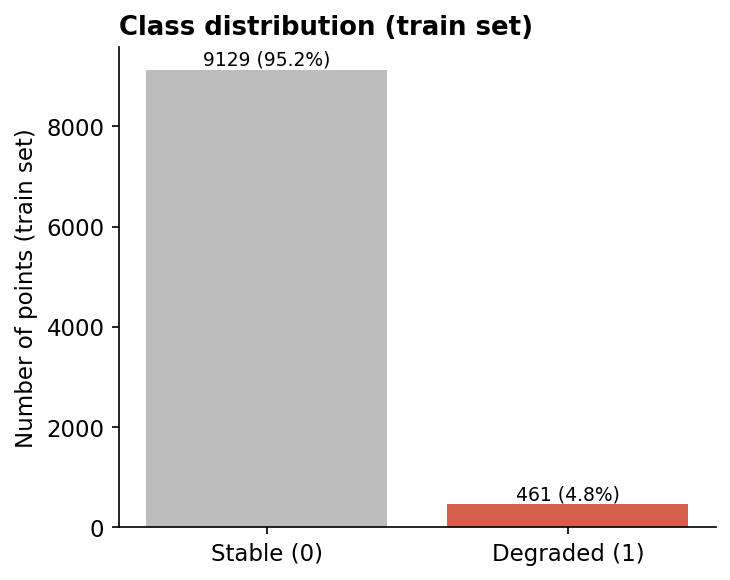

In [ ]:
# ============================================================================
# CELL 2 — TASK 19.1-19.2: CLASS BALANCE & scale_pos_weight
# Requires Cell 1 to have been run first (uses DRIVE_FOLDER, logger, colors).
# Reads y_train.parquet, computes the class distribution and the
# scale_pos_weight XGBoost hyperparameter, saves both to Drive.
# ============================================================================

y_train = pd.read_parquet(f"{DRIVE_FOLDER}/y_train.parquet")["degradation_label"]

n_total = len(y_train)
n_pos = int(y_train.sum())
n_neg = n_total - n_pos
pos_rate = n_pos / n_total
scale_pos_weight = n_neg / n_pos

logger.info(f"Train set: n={n_total}, positive={n_pos} ({pos_rate:.2%}), negative={n_neg}")
logger.info(f"scale_pos_weight = {scale_pos_weight:.4f}")

# --- Save class balance stats ---
class_stats = pd.DataFrame([
    {"class": "Stable (0)", "count": n_neg, "pct": 1 - pos_rate},
    {"class": "Degraded (1)", "count": n_pos, "pct": pos_rate},
])
class_stats.to_csv(f"{DRIVE_FOLDER}/class_balance_stats.csv", index=False)

# --- Save scale_pos_weight for reuse by every downstream model-fitting cell ---
pd.DataFrame([{"scale_pos_weight": scale_pos_weight}]).to_csv(
    f"{DRIVE_FOLDER}/scale_pos_weight_value.csv", index=False
)

# --- Publication figure: class distribution bar chart ---
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(class_stats["class"], class_stats["count"], color=["#bcbcbc", COLOR_ACCENT])
for i, row in class_stats.iterrows():
    ax.text(i, row["count"] + n_total * 0.01, f"{row['count']} ({row['pct']:.1%})",
            ha="center", fontsize=9)
ax.set_ylabel("Number of points (train set)")
ax.set_title("Class distribution (train set)", loc="left")
fig.tight_layout()
fig.savefig(f"{DRIVE_FOLDER}/Class_Distribution_Bar.png", dpi=300, bbox_inches="tight")

logger.info("✓ Saved class_balance_stats.csv, scale_pos_weight_value.csv, Class_Distribution_Bar.png")


## Cell 3 — Task 19.3-19.4: Spatial CV fold assignment & leakage audit

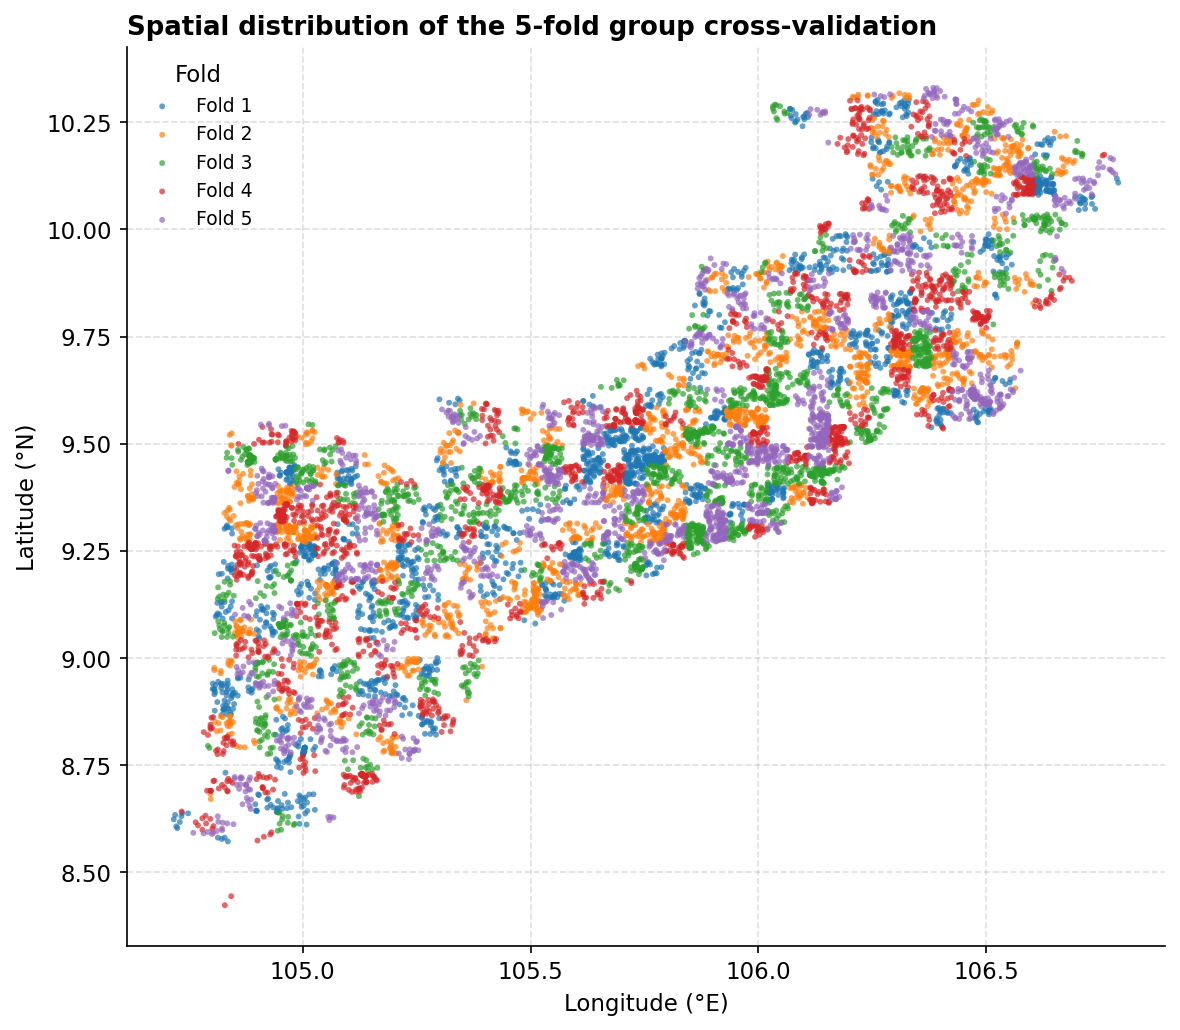

In [ ]:
# ============================================================================
# CELL 3 — TASK 19.3-19.4: SPATIAL CV FOLD ASSIGNMENT & LEAKAGE AUDIT
# Requires Cell 1 to have been run first.
# GroupKFold(n_splits=5) on spatial_block_id ensures no 5x5km block is ever
# split across train/validation within a fold — the core anti-leakage design.
# ============================================================================
from sklearn.model_selection import GroupKFold
from itertools import combinations

EXPECTED_FEATURES = [
    "DEM_Elevation", "loss_to_shrimp", "loss_to_built", "pop_latest",
    "Distance_To_Infra", "Distance_To_Tidal_Channel",
    "IFI_seasonal_amplitude", "NDVI_Trend_2019_2024",
]
EXPECTED_FOLDS = [1, 2, 3, 4, 5]

# --- Load & align feature matrix with the point/block index (by row position) ---
df_features = pd.read_parquet(f"{DRIVE_FOLDER}/Mekong_Train_Dataset_Final.parquet").reset_index(drop=True)
df_index = pd.read_parquet(f"{DRIVE_FOLDER}/Train_Point_ID_Index.parquet").reset_index(drop=True)

assert len(df_features) == len(df_index), \
    f"Row count mismatch: features={len(df_features)}, index={len(df_index)}"
missing_features = [f for f in EXPECTED_FEATURES if f not in df_features.columns]
assert not missing_features, f"Missing expected features: {missing_features}"
assert df_index["point_id"].is_unique, "Duplicate point_id in Train_Point_ID_Index.parquet"
assert df_index["spatial_block_id"].notna().all(), "Missing spatial_block_id values"

df = pd.concat([df_index[["point_id", "spatial_block_id", "lon", "lat"]], df_features], axis=1)
logger.info(f"Loaded and aligned {len(df):,} training points, {df['spatial_block_id'].nunique():,} spatial blocks.")

# --- GroupKFold assignment ---
gkf = GroupKFold(n_splits=5)
df["fold_number"] = -1
for fold_num, (tr_idx, val_idx) in enumerate(gkf.split(df, groups=df["spatial_block_id"]), start=1):
    df.loc[val_idx, "fold_number"] = fold_num
    train_blocks = set(df.iloc[tr_idx]["spatial_block_id"])
    val_blocks = set(df.iloc[val_idx]["spatial_block_id"])
    overlap = train_blocks & val_blocks
    assert not overlap, f"Spatial leakage in fold {fold_num}: {len(overlap)} overlapping blocks"
    logger.info(f"Fold {fold_num}: n={len(val_idx):,} ({len(val_idx)/len(df):.1%}), "
                f"validation blocks={len(val_blocks):,}, block overlap=0")

# --- Global integrity checks ---
assert (df["fold_number"] != -1).all(), "Unassigned samples detected"
assert sorted(df["fold_number"].unique().tolist()) == EXPECTED_FOLDS, "Unexpected fold set"
block_fold_counts = df.groupby("spatial_block_id")["fold_number"].nunique()
assert (block_fold_counts <= 1).all(), "Some spatial blocks span multiple folds"
assert not df["point_id"].duplicated().any(), "Duplicate point_id after fold assignment"
logger.info("✓ All global spatial CV integrity checks passed.")

# --- Pairwise leakage audit table (Task 19.4) — all C(5,2)=10 fold-pair comparisons ---
fold_blocks = {f: set(df[df.fold_number == f]["spatial_block_id"]) for f in EXPECTED_FOLDS}
audit_records = []
for i, j in combinations(EXPECTED_FOLDS, 2):
    overlap = len(fold_blocks[i] & fold_blocks[j])
    audit_records.append({"fold_i": i, "fold_j": j, "overlapping_blocks": overlap,
                           "status": "PASS" if overlap == 0 else "FAIL"})
audit_df = pd.DataFrame(audit_records)
assert (audit_df["status"] == "PASS").all(), "Pairwise leakage audit failed"
audit_df.to_csv(f"{DRIVE_FOLDER}/fold_leakage_check.csv", index=False)
logger.info(f"✓ Pairwise leakage audit: {len(audit_df)}/10 fold pairs PASS (0 overlapping blocks).")

# --- Save fold assignment ---
assignment_df = df[["point_id", "spatial_block_id", "fold_number"]].copy()
assignment_df["fold_number"] = assignment_df["fold_number"].astype(int)
assignment_df.to_csv(f"{DRIVE_FOLDER}/cv_fold_assignment.csv", index=False)
logger.info(f"✓ Saved cv_fold_assignment.csv ({len(assignment_df):,} rows)")

# --- Publication figure: spatial fold map ---
fig, ax = plt.subplots(figsize=(8, 7))
fold_colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]
for fold_number in EXPECTED_FOLDS:
    fold_data = df[df["fold_number"] == fold_number]
    ax.scatter(fold_data["lon"], fold_data["lat"], c=fold_colors[fold_number - 1],
               label=f"Fold {fold_number}", s=8, alpha=0.7, edgecolors="none")
ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°N)")
ax.set_title("Spatial distribution of the 5-fold group cross-validation", loc="left")
ax.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
ax.legend(title="Fold", loc="upper left", fontsize=9)
fig.tight_layout()
fig.savefig(f"{DRIVE_FOLDER}/Spatial_CV_Fold_Map.png", dpi=300, bbox_inches="tight")

logger.info("✓ Saved Spatial_CV_Fold_Map.png")
logger.info("Task 19.3-19.4 complete. cv_fold_assignment.csv is now reusable by Tasks 20.1-20.3.")


## Cell 4 — Task 19.5: SMOTE ablation decision

In [ ]:
# ==============================================================================
# TASK 19.5 - SMOTE ABLATION STUDY
# Mekong Delta Degradation Detection
#
# FINAL COLAB VERSION
#
# INPUTS:
#   1. Mekong_Train_Dataset_Final.parquet
#      -> scaled feature matrix ONLY
#      -> NO label required
#      -> NO point_id required
#
#   2. y_train.parquet
#      -> locked training labels
#
#   3. cv_fold_assignment.csv
#      -> locked 5-fold spatial CV assignment
#
#   4. scale_pos_weight_value.csv
#      -> locked Task 19.2 scale_pos_weight
#
# OUTPUTS:
#   1. SMOTE_Ablation_Metrics.csv
#   2. SMOTE_Decision_Note.csv
#
# IMPORTANT:
#   - SMOTE is applied ONLY to the training partition of each fold.
#   - Validation folds are NEVER oversampled.
#   - No test data is used.
#   - No point_id is artificially created.
#   - X, y and fold assignment are aligned by LOCKED ROW ORDER.
# ==============================================================================


# ==============================================================================
# 0. INSTALL REQUIRED PACKAGE
# ==============================================================================

from google.colab import drive
drive.mount('/content/drive')

DRIVE_FOLDER = "/content/drive/MyDrive/Zenodo_Mekong_Data"

import sys
import subprocess
import importlib.util

if importlib.util.find_spec("imblearn") is None:
    print("Installing imbalanced-learn...")
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "imbalanced-learn"
    ])

print("Required packages are ready.")


# ==============================================================================
# 1. IMPORTS
# ==============================================================================

import os
import sys
import logging
import warnings

import numpy as np
import pandas as pd

from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

warnings.filterwarnings("ignore")


# ==============================================================================
# 2. GOOGLE COLAB SUPPORT
# ==============================================================================

try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False


# ==============================================================================
# 3. LOGGING
# ==============================================================================

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    handlers=[logging.StreamHandler(sys.stdout)]
)

logger = logging.getLogger(__name__)


# ==============================================================================
# 4. FILE PATHS
# ==============================================================================

DATASET_PATH = f"{DRIVE_FOLDER}/Mekong_Train_Dataset_Final.parquet"

Y_TRAIN_PATH = f"{DRIVE_FOLDER}/y_train.parquet"

CV_ASSIGNMENT_PATH = f"{DRIVE_FOLDER}/cv_fold_assignment.csv"

SCALE_POS_WEIGHT_PATH = f"{DRIVE_FOLDER}/scale_pos_weight_value.csv"

OUTPUT_ABLATION_PATH = f"{DRIVE_FOLDER}/SMOTE_Ablation_Metrics.csv"

OUTPUT_DECISION_PATH = f"{DRIVE_FOLDER}/SMOTE_Decision_Note.csv"


# ==============================================================================
# 5. LOCKED MODEL FEATURES
# ==============================================================================

FINAL_FEATURES = [
    "DEM_Elevation",
    "loss_to_shrimp",
    "loss_to_built",
    "pop_latest",
    "Distance_To_Infra",
    "Distance_To_Tidal_Channel",
    "IFI_seasonal_amplitude",
    "NDVI_Trend_2019_2024"
]


# ==============================================================================
# 6. LOCKED CV SETTINGS
# ==============================================================================

EXPECTED_FOLDS = [1, 2, 3, 4, 5]

SMOTE_RANDOM_STATE = 42

MODEL_RANDOM_STATE = 42

TOLERANCE_EPSILON = 1e-4


# ==============================================================================
# 7. BASELINE XGBOOST PARAMETERS
#
# These are the parameters specified for the Task 20.2 default XGBoost setup.
# ==============================================================================

BASELINE_XGB_PARAMS = {
    "n_estimators": 100,
    "learning_rate": 0.1,
    "max_depth": 6,
    "subsample": 1.0,
    "colsample_bytree": 1.0,
    "min_child_weight": 1,
    "eval_metric": "logloss",
    "random_state": MODEL_RANDOM_STATE,
    "n_jobs": -1
}


# ==============================================================================
# 8. COLAB FILE UPLOAD
# ==============================================================================

def ensure_required_files():
    """
    Check all required input files.

    If running in Google Colab, automatically open the upload dialog
    for missing files.
    """

    required_files = [
        DATASET_PATH,
        Y_TRAIN_PATH,
        CV_ASSIGNMENT_PATH,
        SCALE_POS_WEIGHT_PATH
    ]

    missing_files = [
        f for f in required_files
        if not os.path.exists(f)
    ]

    if not missing_files:
        logger.info("All required input files are present.")
        return

    logger.warning("The following required files are missing:")

    for f in missing_files:
        logger.warning(f"  - {f}")

    if not IN_COLAB:
        logger.error(
            "Not running in Google Colab. "
            "Please place all required files in the working directory."
        )
        sys.exit(1)

    logger.info("Please upload the missing files.")

    raise FileNotFoundError("Required file missing from Google Drive folder — check that the earlier task actually wrote it there before re-running this cell.")

    for filename, content in uploaded.items():
        with open(filename, "wb") as f:
            f.write(content)

    # Re-check after upload
    still_missing = [
        f for f in required_files
        if not os.path.exists(f)
    ]

    if still_missing:
        logger.error(
            "The following required files are still missing:"
        )

        for f in still_missing:
            logger.error(f"  - {f}")

        sys.exit(1)

    logger.info("All required files successfully uploaded.")


# ==============================================================================
# 9. LOAD SCALE_POS_WEIGHT
# ==============================================================================

def load_scale_pos_weight():
    """
    Load the officially supplied Task 19.2 scale_pos_weight.

    The file may contain:
        scale_pos_weight
    OR
        value
    OR
        another single numeric column.

    The function does NOT calculate or invent a replacement value.
    """

    logger.info(
        f"Loading scale_pos_weight from: {SCALE_POS_WEIGHT_PATH}"
    )

    try:
        df = pd.read_csv(SCALE_POS_WEIGHT_PATH)
    except Exception as e:
        logger.error(
            f"Failed to read '{SCALE_POS_WEIGHT_PATH}': {e}"
        )
        sys.exit(1)

    logger.info(
        f"scale_pos_weight file columns: {df.columns.tolist()}"
    )

    # ----------------------------------------------------------
    # Preferred column names
    # ----------------------------------------------------------

    preferred_columns = [
        "scale_pos_weight",
        "scale_pos_weight_value",
        "value",
        "Value",
        "SCALE_POS_WEIGHT"
    ]

    selected_column = None

    for col in preferred_columns:
        if col in df.columns:
            selected_column = col
            break

    # ----------------------------------------------------------
    # If no known name exists, search for a single numeric column
    # ----------------------------------------------------------

    if selected_column is None:

        numeric_candidates = []

        for col in df.columns:

            converted = pd.to_numeric(
                df[col],
                errors="coerce"
            )

            if converted.notna().all():
                numeric_candidates.append(col)

        if len(numeric_candidates) == 1:
            selected_column = numeric_candidates[0]

        else:
            logger.error(
                "Could not uniquely identify scale_pos_weight "
                "inside the supplied CSV."
            )

            logger.error(
                f"Available columns: {df.columns.tolist()}"
            )

            sys.exit(1)

    # ----------------------------------------------------------
    # Validate exactly one value
    # ----------------------------------------------------------

    values = pd.to_numeric(
        df[selected_column],
        errors="coerce"
    ).dropna()

    if len(values) != 1:
        logger.error(
            "scale_pos_weight file must contain exactly one "
            "valid numeric value."
        )

        logger.error(
            f"Detected values: {values.tolist()}"
        )

        sys.exit(1)

    scale_pos_weight = float(values.iloc[0])

    if not np.isfinite(scale_pos_weight):
        logger.error(
            "scale_pos_weight is not finite."
        )
        sys.exit(1)

    if scale_pos_weight <= 0:
        logger.error(
            f"Invalid scale_pos_weight = {scale_pos_weight}"
        )
        sys.exit(1)

    logger.info(
        f"LOCKED Task 19.2 scale_pos_weight = "
        f"{scale_pos_weight:.10f}"
    )

    return scale_pos_weight


# ==============================================================================
# 10. LOAD FEATURE DATASET
# ==============================================================================

def load_feature_dataset():
    """
    Load Mekong_Train_Dataset_Final.parquet.

    IMPORTANT:
    This file is expected to contain FEATURES ONLY.

    No label is required.
    No point_id is required.
    """

    logger.info(
        f"Loading feature dataset: {DATASET_PATH}"
    )

    try:
        X = pd.read_parquet(DATASET_PATH)
    except Exception as e:
        logger.error(
            f"Failed to read dataset: {e}"
        )
        sys.exit(1)

    logger.info(
        f"Raw feature dataset shape: {X.shape}"
    )

    # ----------------------------------------------------------
    # Reset index without treating it as a feature
    # ----------------------------------------------------------

    if isinstance(X.index, pd.MultiIndex):
        X = X.reset_index(drop=True)
    else:
        X = X.reset_index(drop=True)

    # ----------------------------------------------------------
    # Flatten MultiIndex columns if necessary
    # ----------------------------------------------------------

    if isinstance(X.columns, pd.MultiIndex):

        flattened_columns = []

        for col in X.columns:

            parts = [
                str(part).strip()
                for part in col
                if str(part).strip()
                and not str(part).startswith("Unnamed")
            ]

            if parts:
                flattened_columns.append(parts[0])
            else:
                flattened_columns.append("unknown")

        X.columns = flattened_columns

    # ----------------------------------------------------------
    # Normalize column names
    # ----------------------------------------------------------

    X.columns = [
        str(c).strip()
        for c in X.columns
    ]

    # ----------------------------------------------------------
    # Check required features
    # ----------------------------------------------------------

    missing_features = [
        feature
        for feature in FINAL_FEATURES
        if feature not in X.columns
    ]

    if missing_features:

        logger.error(
            "Critical feature lineage error."
        )

        logger.error(
            f"Missing required features: {missing_features}"
        )

        logger.error(
            f"Available columns: {X.columns.tolist()}"
        )

        sys.exit(1)

    # ----------------------------------------------------------
    # Select ONLY locked features
    # ----------------------------------------------------------

    X = X[FINAL_FEATURES].copy()

    # ----------------------------------------------------------
    # Numeric validation
    # ----------------------------------------------------------

    for feature in FINAL_FEATURES:

        X[feature] = pd.to_numeric(
            X[feature],
            errors="coerce"
        )

    # ----------------------------------------------------------
    # Missing-value check
    # ----------------------------------------------------------

    missing_counts = X.isna().sum()

    if missing_counts.sum() > 0:

        logger.error(
            "Critical data error: missing values detected "
            "in final model features."
        )

        logger.error(
            missing_counts[missing_counts > 0].to_dict()
        )

        sys.exit(1)

    # ----------------------------------------------------------
    # Infinite-value check
    # ----------------------------------------------------------

    if not np.isfinite(X.to_numpy(dtype=float)).all():

        logger.error(
            "Critical data error: infinite values detected "
            "in final model features."
        )

        sys.exit(1)

    logger.info(
        f"Final feature matrix shape: {X.shape}"
    )

    logger.info(
        f"Locked features: {FINAL_FEATURES}"
    )

    return X


# ==============================================================================
# 11. LOAD y_train
# ==============================================================================

def load_y_train():
    """
    Load y_train.parquet.

    y_train may be:
        - a Series-like single-column parquet
        - a one-column DataFrame

    The function extracts the single label vector.
    """

    logger.info(
        f"Loading labels: {Y_TRAIN_PATH}"
    )

    try:
        y_raw = pd.read_parquet(Y_TRAIN_PATH)
    except Exception as e:
        logger.error(
            f"Failed to read y_train: {e}"
        )
        sys.exit(1)

    logger.info(
        f"Raw y_train shape: {y_raw.shape}"
    )

    # ----------------------------------------------------------
    # Handle Series
    # ----------------------------------------------------------

    if isinstance(y_raw, pd.Series):

        y = y_raw.copy()

    # ----------------------------------------------------------
    # Handle DataFrame
    # ----------------------------------------------------------

    else:

        if y_raw.shape[1] != 1:

            # Try to find a standard label column
            label_candidates = [
                "degradation_label",
                "label",
                "target",
                "y"
            ]

            matching = [
                c for c in label_candidates
                if c in y_raw.columns
            ]

            if len(matching) == 1:
                y = y_raw[matching[0]].copy()

            else:
                logger.error(
                    "y_train.parquet must contain exactly one "
                    "label column."
                )

                logger.error(
                    f"Available columns: {y_raw.columns.tolist()}"
                )

                sys.exit(1)

        else:
            y = y_raw.iloc[:, 0].copy()

    # ----------------------------------------------------------
    # Reset row order
    # ----------------------------------------------------------

    y = y.reset_index(drop=True)

    # ----------------------------------------------------------
    # Convert to numeric
    # ----------------------------------------------------------

    y = pd.to_numeric(
        y,
        errors="coerce"
    )

    # ----------------------------------------------------------
    # Missing label check
    # ----------------------------------------------------------

    if y.isna().any():

        logger.error(
            "Critical label lineage error: y_train contains "
            "missing values."
        )

        sys.exit(1)

    # ----------------------------------------------------------
    # Binary label check
    # ----------------------------------------------------------

    unique_labels = sorted(
        y.unique().tolist()
    )

    if unique_labels != [0, 1]:

        logger.error(
            "Critical label lineage error."
        )

        logger.error(
            f"Expected labels [0, 1], found {unique_labels}"
        )

        sys.exit(1)

    logger.info(
        f"y_train length: {len(y)}"
    )

    logger.info(
        f"Class distribution: {y.value_counts().sort_index().to_dict()}"
    )

    return y.astype(int)


# ==============================================================================
# 12. LOAD CV FOLD ASSIGNMENT
# ==============================================================================

def load_cv_assignment(expected_n_rows):
    """
    Load cv_fold_assignment.csv.

    Because the feature dataset does NOT contain point_id,
    this implementation uses LOCKED ROW ORDER.

    The CSV must contain:
        fold_number
    OR a recognized equivalent column.

    The number of rows must exactly equal X and y_train.
    """

    logger.info(
        f"Loading CV assignment: {CV_ASSIGNMENT_PATH}"
    )

    try:
        df_cv = pd.read_csv(
            CV_ASSIGNMENT_PATH
        )
    except Exception as e:
        logger.error(
            f"Failed to read CV assignment: {e}"
        )
        sys.exit(1)

    logger.info(
        f"CV assignment shape: {df_cv.shape}"
    )

    # ----------------------------------------------------------
    # Detect fold column
    # ----------------------------------------------------------

    fold_column = None

    possible_fold_columns = [
        "fold_number",
        "fold",
        "fold_num",
        "fold_no",
        "folds"
    ]

    for col in possible_fold_columns:

        if col in df_cv.columns:
            fold_column = col
            break

    if fold_column is None:

        logger.error(
            "Critical CV lineage error: no fold column found."
        )

        logger.error(
            f"Available columns: {df_cv.columns.tolist()}"
        )

        sys.exit(1)

    logger.info(
        f"Using CV fold column: '{fold_column}'"
    )

    # ----------------------------------------------------------
    # Row count verification
    # ----------------------------------------------------------

    if len(df_cv) != expected_n_rows:

        logger.error(
            "Critical CV lineage error: row count mismatch."
        )

        logger.error(
            f"Feature rows: {expected_n_rows}"
        )

        logger.error(
            f"CV assignment rows: {len(df_cv)}"
        )

        logger.error(
            "Because point_id is absent from the final feature "
            "dataset, safe alignment requires identical row order "
            "and identical row count."
        )

        sys.exit(1)

    # ----------------------------------------------------------
    # Extract fold vector
    # ----------------------------------------------------------

    folds = pd.to_numeric(
        df_cv[fold_column],
        errors="coerce"
    )

    if folds.isna().any():

        logger.error(
            "Critical CV lineage error: fold assignment "
            "contains missing/non-numeric values."
        )

        sys.exit(1)

    # ----------------------------------------------------------
    # Integer conversion
    # ----------------------------------------------------------

    if not np.all(
        folds.astype(int).to_numpy()
        == folds.to_numpy()
    ):

        logger.error(
            "Critical CV lineage error: fold numbers "
            "must be integers."
        )

        sys.exit(1)

    folds = folds.astype(int)

    # ----------------------------------------------------------
    # Expected folds
    # ----------------------------------------------------------

    actual_folds = sorted(
        folds.unique().tolist()
    )

    if actual_folds != EXPECTED_FOLDS:

        logger.error(
            "Critical CV lineage error."
        )

        logger.error(
            f"Expected folds: {EXPECTED_FOLDS}"
        )

        logger.error(
            f"Found folds: {actual_folds}"
        )

        sys.exit(1)

    # ----------------------------------------------------------
    # Check each fold is non-empty
    # ----------------------------------------------------------

    fold_counts = folds.value_counts().sort_index()

    if (fold_counts == 0).any():

        logger.error(
            "One or more expected CV folds are empty."
        )

        sys.exit(1)

    logger.info(
        f"Verified spatial folds: {actual_folds}"
    )

    logger.info(
        f"Fold sizes: {fold_counts.to_dict()}"
    )

    return folds.reset_index(drop=True)


# ==============================================================================
# 13. METRIC CALCULATION
# ==============================================================================

def calculate_metrics(
    y_true,
    y_pred,
    y_probability
):

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    unique_classes = np.unique(y_true)

    if len(unique_classes) < 2:

        roc_auc = np.nan
        pr_auc = np.nan

    else:

        roc_auc = roc_auc_score(
            y_true,
            y_probability
        )

        pr_auc = average_precision_score(
            y_true,
            y_probability
        )

    return {
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "PR-AUC": pr_auc,
        "ROC-AUC": roc_auc
    }


# ==============================================================================
# 14. BUILD XGBOOST MODEL
# ==============================================================================

def build_xgb(scale_pos_weight):

    params = BASELINE_XGB_PARAMS.copy()

    params["scale_pos_weight"] = scale_pos_weight

    return XGBClassifier(**params)


# ==============================================================================
# 15. MAIN TASK 19.5
# ==============================================================================

def execute_task_19_5():

    logger.info("=" * 80)
    logger.info("TASK 19.5 - SMOTE ABLATION STUDY")
    logger.info("=" * 80)

    # --------------------------------------------------------------------------
    # STEP 0
    # --------------------------------------------------------------------------

    ensure_required_files()

    # --------------------------------------------------------------------------
    # STEP 1 - LOAD LOCKED SCALE_POS_WEIGHT
    # --------------------------------------------------------------------------

    scale_pos_weight = load_scale_pos_weight()

    # --------------------------------------------------------------------------
    # STEP 2 - LOAD FEATURES
    # --------------------------------------------------------------------------

    X = load_feature_dataset()

    # --------------------------------------------------------------------------
    # STEP 3 - LOAD LABELS
    # --------------------------------------------------------------------------

    y = load_y_train()

    # --------------------------------------------------------------------------
    # STEP 4 - STRICT X/Y ALIGNMENT
    # --------------------------------------------------------------------------

    if len(X) != len(y):

        logger.error(
            "CRITICAL LINEAGE ERROR: X and y_train have "
            "different numbers of rows."
        )

        logger.error(
            f"X rows = {len(X)}"
        )

        logger.error(
            f"y rows = {len(y)}"
        )

        sys.exit(1)

    logger.info(
        "X/y row-count alignment verified."
    )

    # --------------------------------------------------------------------------
    # STEP 5 - LOAD CV ASSIGNMENT
    # --------------------------------------------------------------------------

    folds = load_cv_assignment(
        expected_n_rows=len(X)
    )

    # --------------------------------------------------------------------------
    # STEP 6 - FINAL ALIGNMENT CHECK
    # --------------------------------------------------------------------------

    if not (
        len(X)
        == len(y)
        == len(folds)
    ):

        logger.error(
            "CRITICAL LINEAGE ERROR: X, y and fold vectors "
            "are not aligned in length."
        )

        sys.exit(1)

    logger.info(
        "X + y_train + CV fold row-order alignment VERIFIED."
    )

    logger.warning(
        "NOTE: point_id is absent from Mekong_Train_Dataset_Final.parquet. "
        "Therefore Task 19.3 fold assignments are aligned by locked row order, "
        "not by point_id."
    )

    # --------------------------------------------------------------------------
    # STEP 7 - PREPARE RESULTS
    # --------------------------------------------------------------------------

    no_smote_fold_metrics = []

    smote_fold_metrics = []

    # --------------------------------------------------------------------------
    # STEP 8 - PAIRED 5-FOLD SPATIAL CV
    # --------------------------------------------------------------------------

    for fold in EXPECTED_FOLDS:

        logger.info("-" * 80)
        logger.info(f"PROCESSING FOLD {fold}")
        logger.info("-" * 80)

        # ------------------------------------------------------
        # Training / validation masks
        # ------------------------------------------------------

        train_mask = folds != fold
        validation_mask = folds == fold

        X_train = X.loc[train_mask].copy()
        y_train_fold = y.loc[train_mask].copy()

        X_validation = X.loc[validation_mask].copy()
        y_validation = y.loc[validation_mask].copy()

        # ------------------------------------------------------
        # Verify both classes in training
        # ------------------------------------------------------

        train_class_counts = (
            y_train_fold
            .value_counts()
            .sort_index()
        )

        validation_class_counts = (
            y_validation
            .value_counts()
            .sort_index()
        )

        logger.info(
            f"Fold {fold} training class distribution: "
            f"{train_class_counts.to_dict()}"
        )

        logger.info(
            f"Fold {fold} validation class distribution: "
            f"{validation_class_counts.to_dict()}"
        )

        if len(train_class_counts) != 2:

            logger.error(
                f"Fold {fold}: training partition does not "
                f"contain both classes."
            )

            sys.exit(1)

        if len(validation_class_counts) != 2:

            logger.error(
                f"Fold {fold}: validation partition does not "
                f"contain both classes."
            )

            sys.exit(1)

        # ======================================================
        # BRANCH A
        # WITHOUT SMOTE
        #
        # Original cost-sensitive XGBoost
        # ======================================================

        logger.info(
            f"Fold {fold}: Training WITHOUT SMOTE..."
        )

        model_no_smote = build_xgb(
            scale_pos_weight=scale_pos_weight
        )

        model_no_smote.fit(
            X_train,
            y_train_fold
        )

        probability_no_smote = (
            model_no_smote
            .predict_proba(X_validation)[:, 1]
        )

        prediction_no_smote = (
            probability_no_smote >= 0.5
        ).astype(int)

        metrics_no_smote = calculate_metrics(
            y_validation,
            prediction_no_smote,
            probability_no_smote
        )

        no_smote_fold_metrics.append(
            metrics_no_smote
        )

        # ======================================================
        # BRANCH B
        # WITH SMOTE
        #
        # SMOTE ONLY ON TRAINING PARTITION
        # ======================================================

        logger.info(
            f"Fold {fold}: Applying SMOTE ONLY to training data..."
        )

        smote = SMOTE(
            random_state=SMOTE_RANDOM_STATE
        )

        X_train_smote, y_train_smote = (
            smote.fit_resample(
                X_train,
                y_train_fold
            )
        )

        # ------------------------------------------------------
        # Verify SMOTE balancing
        # ------------------------------------------------------

        smote_class_counts = (
            pd.Series(y_train_smote)
            .value_counts()
            .sort_index()
        )

        logger.info(
            f"Fold {fold} post-SMOTE class distribution: "
            f"{smote_class_counts.to_dict()}"
        )

        if len(smote_class_counts) != 2:

            logger.error(
                f"Fold {fold}: SMOTE did not produce both classes."
            )

            sys.exit(1)

        if (
            smote_class_counts.iloc[0]
            != smote_class_counts.iloc[1]
        ):

            logger.error(
                f"Fold {fold}: SMOTE did not produce balanced classes."
            )

            sys.exit(1)

        # ------------------------------------------------------
        # Train SMOTE XGBoost
        #
        # scale_pos_weight = 1.0
        #
        # This isolates the SMOTE effect and avoids
        # double correction of class imbalance.
        # ------------------------------------------------------

        model_smote = build_xgb(
            scale_pos_weight=1.0
        )

        model_smote.fit(
            X_train_smote,
            y_train_smote
        )

        # ------------------------------------------------------
        # IMPORTANT:
        # Validation remains COMPLETELY untouched.
        # ------------------------------------------------------

        probability_smote = (
            model_smote
            .predict_proba(X_validation)[:, 1]
        )

        prediction_smote = (
            probability_smote >= 0.5
        ).astype(int)

        metrics_smote = calculate_metrics(
            y_validation,
            prediction_smote,
            probability_smote
        )

        smote_fold_metrics.append(
            metrics_smote
        )

        # ------------------------------------------------------
        # Fold report
        # ------------------------------------------------------

        logger.info(
            f"Fold {fold} | "
            f"No SMOTE: "
            f"F1={metrics_no_smote['F1']:.4f}, "
            f"PR-AUC={metrics_no_smote['PR-AUC']:.4f} | "
            f"SMOTE: "
            f"F1={metrics_smote['F1']:.4f}, "
            f"PR-AUC={metrics_smote['PR-AUC']:.4f}"
        )

    # ==============================================================================
    # 16. CREATE FOLD METRIC DATAFRAMES
    # ==============================================================================

    df_no_smote = pd.DataFrame(
        no_smote_fold_metrics
    )

    df_smote = pd.DataFrame(
        smote_fold_metrics
    )

    metric_columns = [
        "Precision",
        "Recall",
        "F1",
        "PR-AUC",
        "ROC-AUC"
    ]

    # ==============================================================================
    # 17. STRICT METRIC VALIDATION
    # ==============================================================================

    for metric in metric_columns:

        if df_no_smote[metric].isna().any():

            logger.error(
                f"No-SMOTE {metric} contains NaN."
            )

            sys.exit(1)

        if df_smote[metric].isna().any():

            logger.error(
                f"SMOTE {metric} contains NaN."
            )

            sys.exit(1)

    # ==============================================================================
    # 18. CALCULATE MEAN ± STD
    # ==============================================================================

    no_smote_mean = df_no_smote.mean()
    no_smote_std = df_no_smote.std(ddof=1)

    smote_mean = df_smote.mean()
    smote_std = df_smote.std(ddof=1)

    # ==============================================================================
    # 19. PAIRED DIFFERENCES
    # ==============================================================================

    paired_difference = (
        df_smote[metric_columns]
        - df_no_smote[metric_columns]
    )

    difference_mean = paired_difference.mean()

    difference_std = paired_difference.std(
        ddof=1
    )

    # ==============================================================================
    # 20. PRINT BASELINE RESULTS
    # ==============================================================================

    logger.info("=" * 80)
    logger.info("5-FOLD NO-SMOTE BASELINE")
    logger.info("=" * 80)

    for metric in metric_columns:

        logger.info(
            f"{metric}: "
            f"{no_smote_mean[metric]:.6f} ± "
            f"{no_smote_std[metric]:.6f}"
        )

    # ==============================================================================
    # 21. PRINT SMOTE RESULTS
    # ==============================================================================

    logger.info("=" * 80)
    logger.info("5-FOLD SMOTE RESULTS")
    logger.info("=" * 80)

    for metric in metric_columns:

        logger.info(
            f"{metric}: "
            f"{smote_mean[metric]:.6f} ± "
            f"{smote_std[metric]:.6f}"
        )

    # ==============================================================================
    # 22. PRINT PAIRED DIFFERENCES
    # ==============================================================================

    logger.info("=" * 80)
    logger.info("PAIRED DIFFERENCE: SMOTE - NO SMOTE")
    logger.info("=" * 80)

    for metric in metric_columns:

        logger.info(
            f"{metric}: "
            f"{difference_mean[metric]:+.6f} ± "
            f"{difference_std[metric]:.6f}"
        )

    # ==============================================================================
    # 23. DECISION RULE
    #
    # USE SMOTE ONLY IF:
    #
    #   Mean PR-AUC improves strictly
    #   AND
    #   Mean F1 does not decrease
    #
    # This decision is fixed before Task 20.3.
    # ==============================================================================

    mean_pr_auc_no_smote = (
        no_smote_mean["PR-AUC"]
    )

    mean_pr_auc_smote = (
        smote_mean["PR-AUC"]
    )

    mean_f1_no_smote = (
        no_smote_mean["F1"]
    )

    mean_f1_smote = (
        smote_mean["F1"]
    )

    use_smote = (
        mean_pr_auc_smote
        > mean_pr_auc_no_smote
    ) and (
        mean_f1_smote
        >= mean_f1_no_smote
    )

    if use_smote:

        final_decision = (
            "USE_SMOTE_IN_TUNING"
        )

    else:

        final_decision = (
            "DO_NOT_USE_SMOTE_IN_TUNING"
        )

    # ==============================================================================
    # 24. CREATE SMOTE_ABLATION_METRICS.CSV
    # ==============================================================================

    summary_no_smote = {
        "Configuration":
            "Without SMOTE (Cost-sensitive XGBoost)",
        "Precision":
            f"{no_smote_mean['Precision']:.4f} ± "
            f"{no_smote_std['Precision']:.4f}",
        "Recall":
            f"{no_smote_mean['Recall']:.4f} ± "
            f"{no_smote_std['Recall']:.4f}",
        "F1":
            f"{no_smote_mean['F1']:.4f} ± "
            f"{no_smote_std['F1']:.4f}",
        "PR-AUC":
            f"{no_smote_mean['PR-AUC']:.4f} ± "
            f"{no_smote_std['PR-AUC']:.4f}",
        "ROC-AUC":
            f"{no_smote_mean['ROC-AUC']:.4f} ± "
            f"{no_smote_std['ROC-AUC']:.4f}"
    }

    summary_smote = {
        "Configuration":
            "With SMOTE (scale_pos_weight = 1.0)",
        "Precision":
            f"{smote_mean['Precision']:.4f} ± "
            f"{smote_std['Precision']:.4f}",
        "Recall":
            f"{smote_mean['Recall']:.4f} ± "
            f"{smote_std['Recall']:.4f}",
        "F1":
            f"{smote_mean['F1']:.4f} ± "
            f"{smote_std['F1']:.4f}",
        "PR-AUC":
            f"{smote_mean['PR-AUC']:.4f} ± "
            f"{smote_std['PR-AUC']:.4f}",
        "ROC-AUC":
            f"{smote_mean['ROC-AUC']:.4f} ± "
            f"{smote_std['ROC-AUC']:.4f}"
    }

    summary_difference = {
        "Configuration":
            "Paired Difference (SMOTE - No SMOTE)",
        "Precision":
            f"{difference_mean['Precision']:+.4f} ± "
            f"{difference_std['Precision']:.4f}",
        "Recall":
            f"{difference_mean['Recall']:+.4f} ± "
            f"{difference_std['Recall']:.4f}",
        "F1":
            f"{difference_mean['F1']:+.4f} ± "
            f"{difference_std['F1']:.4f}",
        "PR-AUC":
            f"{difference_mean['PR-AUC']:+.4f} ± "
            f"{difference_std['PR-AUC']:.4f}",
        "ROC-AUC":
            f"{difference_mean['ROC-AUC']:+.4f} ± "
            f"{difference_std['ROC-AUC']:.4f}"
    }

    df_ablation = pd.DataFrame([
        summary_no_smote,
        summary_smote,
        summary_difference
    ])

    df_ablation = df_ablation[
        [
            "Configuration",
            "Precision",
            "Recall",
            "F1",
            "PR-AUC",
            "ROC-AUC"
        ]
    ]

    df_ablation.to_csv(
        OUTPUT_ABLATION_PATH,
        index=False
    )

    # ==============================================================================
    # 25. CREATE SMOTE_DECISION_NOTE.CSV
    # ==============================================================================

    decision_data = {

        "final_decision":
            final_decision,

        "use_smote_in_20_3":
            use_smote,

        "decision_rule":
            "USE_SMOTE only if mean PR-AUC strictly improves "
            "and mean F1 does not decrease",

        "scale_pos_weight_task_19_2":
            round(scale_pos_weight, 8),

        "pr_auc_no_smote":
            round(mean_pr_auc_no_smote, 6),

        "pr_auc_with_smote":
            round(mean_pr_auc_smote, 6),

        "delta_pr_auc_mean":
            round(
                difference_mean["PR-AUC"],
                6
            ),

        "delta_pr_auc_std":
            round(
                difference_std["PR-AUC"],
                6
            ),

        "f1_no_smote":
            round(mean_f1_no_smote, 6),

        "f1_with_smote":
            round(mean_f1_smote, 6),

        "delta_f1_mean":
            round(
                difference_mean["F1"],
                6
            ),

        "delta_f1_std":
            round(
                difference_std["F1"],
                6
            ),

        "cv_scheme":
            "Locked 5-fold spatial CV from cv_fold_assignment.csv",

        "smote_application":
            "Training folds only; validation folds untouched",

        "alignment_method":
            "Locked row-order alignment because point_id is absent "
            "from Mekong_Train_Dataset_Final.parquet",

        "n_samples":
            len(X),

        "n_features":
            len(FINAL_FEATURES)
    }

    df_decision = pd.DataFrame(
        [decision_data]
    )

    df_decision.to_csv(
        OUTPUT_DECISION_PATH,
        index=False
    )

    # ==============================================================================
    # 26. FINAL REPORT
    # ==============================================================================

    logger.info("=" * 80)
    logger.info("TASK 19.5 COMPLETED SUCCESSFULLY")
    logger.info("=" * 80)

    logger.info(
        f"Output 1: {OUTPUT_ABLATION_PATH}"
    )

    logger.info(
        f"Output 2: {OUTPUT_DECISION_PATH}"
    )

    logger.info(
        f"Final decision: {final_decision}"
    )

    logger.info(
        f"Mean PR-AUC without SMOTE: "
        f"{mean_pr_auc_no_smote:.6f}"
    )

    logger.info(
        f"Mean PR-AUC with SMOTE: "
        f"{mean_pr_auc_smote:.6f}"
    )

    logger.info(
        f"Mean Δ PR-AUC: "
        f"{difference_mean['PR-AUC']:+.6f}"
    )

    logger.info(
        f"Mean F1 without SMOTE: "
        f"{mean_f1_no_smote:.6f}"
    )

    logger.info(
        f"Mean F1 with SMOTE: "
        f"{mean_f1_smote:.6f}"
    )

    logger.info(
        f"Mean Δ F1: "
        f"{difference_mean['F1']:+.6f}"
    )

    logger.info("=" * 80)

    # ==============================================================================
    # 27. DOWNLOAD OUTPUTS IN COLAB
    # ==============================================================================

    if IN_COLAB:

        logger.info(
            "Downloading output CSV files..."
        )

        pass  # output already saved directly to Google Drive, no download needed
        pass  # output already saved directly to Google Drive, no download needed
# ==============================================================================
# 28. RUN
# ==============================================================================

if __name__ == "__main__":

    execute_task_19_5()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Required packages are ready.


## Cell 5 — Task 20.1: Baseline models (Logistic Regression, Random Forest)

In [ ]:
# ==============================================================================
# TASK 20.1
# CLASSICAL BASELINE MODELS EVALUATION
# Logistic Regression + Random Forest
# 5-Fold Locked Spatial Cross-Validation
#
# INPUT ARTIFACTS:
#   1. X_train_no_multico (ALREADY SCALED)
#   2. X_test_no_multico  (ALREADY SCALED)
#   3. y_train
#   4. y_test
#   5. cv_fold_assignment.csv
#
# IMPORTANT:
#   - NO StandardScaler is applied.
#   - X_test / y_test are NOT used during CV.
#   - cv_fold_assignment.csv is used ONLY for training-set spatial CV.
# ==============================================================================

from google.colab import drive
drive.mount('/content/drive')

DRIVE_FOLDER = "/content/drive/MyDrive/Zenodo_Mekong_Data"

import os
import sys
import logging
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve
)

warnings.filterwarnings("ignore")

# ==============================================================================
# LOGGING
# ==============================================================================

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    handlers=[logging.StreamHandler(sys.stdout)],
    force=True
)

logger = logging.getLogger(__name__)

# ==============================================================================
# CONFIGURATION
# ==============================================================================

EXPECTED_FOLDS = [1, 2, 3, 4, 5]

FEATURES_NO_MULTICO = [
    "DEM_Elevation",
    "loss_to_shrimp",
    "loss_to_built",
    "pop_latest",
    "Distance_To_Infra",
    "Distance_To_Tidal_Channel",
    "IFI_seasonal_amplitude",
    "NDVI_Trend_2019_2024"
]

OUTPUT_SUMMARY_METRICS_PATH = f"{DRIVE_FOLDER}/Task20_1_Baseline_Metrics_Table.csv"
OUTPUT_FOLDWISE_METRICS_PATH = f"{DRIVE_FOLDER}/Task20_1_Baseline_Foldwise_Metrics.csv"
OUTPUT_OOF_PREDICTIONS_PATH = f"{DRIVE_FOLDER}/Task20_1_OOF_Predictions.csv"
OUTPUT_PR_CURVE_PATH = f"{DRIVE_FOLDER}/Task20_1_Baseline_PR_Curve.png"

# ==============================================================================
# COLAB DETECTION
# ==============================================================================

try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# ==============================================================================
# HELPER: NORMALIZE COLUMN NAMES
# ==============================================================================

def normalize_columns(df):
    """
    Safely normalize DataFrame column names.
    Does NOT change data values.
    """
    df = df.copy()

    cleaned = []

    for col in df.columns:
        col_str = str(col).strip()

        # Remove accidental tuple-like formatting
        col_str = col_str.strip("()")

        # Handle tuple strings such as:
        # ('DEM_Elevation', '')
        if "," in col_str and col_str.startswith("'"):
            col_str = col_str.split(",")[0]
            col_str = col_str.strip(" '\"")

        cleaned.append(col_str)

    df.columns = cleaned

    return df


# ==============================================================================
# HELPER: LOAD ANY DATA FILE
# ==============================================================================

def load_data_file(path):
    """
    Load common tabular / serialized formats.
    """

    ext = os.path.splitext(path)[1].lower()

    logger.info(f"Loading: {path}")

    # --------------------------------------------------------------------------
    # CSV
    # --------------------------------------------------------------------------
    if ext == ".csv":
        return pd.read_csv(path)

    # --------------------------------------------------------------------------
    # PARQUET
    # --------------------------------------------------------------------------
    elif ext == ".parquet":
        return pd.read_parquet(path)

    # --------------------------------------------------------------------------
    # PICKLE
    # --------------------------------------------------------------------------
    elif ext in [".pkl", ".pickle"]:
        return pd.read_pickle(path)

    # --------------------------------------------------------------------------
    # NUMPY
    # --------------------------------------------------------------------------
    elif ext == ".npy":
        return np.load(path, allow_pickle=True)

    elif ext == ".npz":
        data = np.load(path, allow_pickle=True)

        # If only one array exists
        if len(data.files) == 1:
            return data[data.files[0]]

        return {
            key: data[key]
            for key in data.files
        }

    # --------------------------------------------------------------------------
    # EXCEL
    # --------------------------------------------------------------------------
    elif ext in [".xlsx", ".xls"]:
        return pd.read_excel(path)

    else:
        raise ValueError(
            f"Unsupported file format: {ext}. "
            f"Supported: csv, parquet, pkl, pickle, npy, npz, xlsx, xls"
        )


# ==============================================================================
# HELPER: CONVERT TO DATAFRAME
# ==============================================================================

def ensure_dataframe(obj, name):
    """
    Convert loaded object into DataFrame whenever possible.
    """

    if isinstance(obj, pd.DataFrame):
        df = obj.copy()

    elif isinstance(obj, pd.Series):
        df = obj.to_frame()

    elif isinstance(obj, np.ndarray):

        if obj.ndim == 1:
            df = pd.DataFrame(obj, columns=[name])

        elif obj.ndim == 2:
            df = pd.DataFrame(obj)

        else:
            raise ValueError(
                f"{name} has unsupported ndarray dimension: {obj.ndim}"
            )

    else:
        raise ValueError(
            f"Cannot convert {name} of type {type(obj)} to DataFrame."
        )

    return normalize_columns(df)


# ==============================================================================
# HELPER: IDENTIFY FILE
# ==============================================================================

def find_uploaded_file(uploaded_files, keywords, extensions=None):
    """
    Find uploaded file by keyword matching.
    """

    if extensions is None:
        extensions = []

    candidates = []

    for filename in uploaded_files:

        lower_name = filename.lower()

        if extensions:
            if not any(lower_name.endswith(ext) for ext in extensions):
                continue

        score = 0

        for keyword in keywords:
            if keyword.lower() in lower_name:
                score += 1

        if score > 0:
            candidates.append((score, filename))

    if not candidates:
        return None

    candidates.sort(reverse=True)

    return candidates[0][1]


# ==============================================================================
# STEP 0 — UPLOAD INPUT FILES
# ==============================================================================

def load_task_inputs():
    """
    Load the 5 required artifacts directly from Google Drive
    (replaces the old upload-dialog + keyword-search discovery mechanism).
    """
    x_train_file = f"{DRIVE_FOLDER}/X_train_no_multico.parquet"
    x_test_file = f"{DRIVE_FOLDER}/X_test_no_multico.parquet"
    y_train_file = f"{DRIVE_FOLDER}/y_train.parquet"
    y_test_file = f"{DRIVE_FOLDER}/y_test.parquet"
    cv_file = f"{DRIVE_FOLDER}/cv_fold_assignment.csv"

    logger.info("=" * 80)
    logger.info("TASK 20.1 — LOADING INPUT FILES FROM GOOGLE DRIVE")
    logger.info("=" * 80)
    logger.info(f"X_train file : {x_train_file}")
    logger.info(f"X_test file  : {x_test_file}")
    logger.info(f"y_train file : {y_train_file}")
    logger.info(f"y_test file  : {y_test_file}")
    logger.info(f"CV file      : {cv_file}")

    missing = [f for f in [x_train_file, x_test_file, y_train_file, y_test_file, cv_file] if not os.path.exists(f)]
    if missing:
        raise FileNotFoundError(
            "The following required files are missing from Google Drive — "
            "check that the earlier task actually wrote them there before re-running this cell:\n"
            + "\n".join(missing)
        )
    logger.info("All 5 required input files found on Google Drive.")


    # --------------------------------------------------------------------------
    # Load
    # --------------------------------------------------------------------------

    X_train = ensure_dataframe(
        load_data_file(x_train_file),
        "X_train_no_multico"
    )

    X_test = ensure_dataframe(
        load_data_file(x_test_file),
        "X_test_no_multico"
    )

    y_train = load_data_file(y_train_file)
    y_test = load_data_file(y_test_file)

    # --------------------------------------------------------------------------
    # y conversion
    # --------------------------------------------------------------------------

    if isinstance(y_train, pd.DataFrame):

        # If one-column dataframe
        if y_train.shape[1] == 1:
            y_train = y_train.iloc[:, 0]

        else:
            # Try target-like column
            possible = [
                c for c in y_train.columns
                if str(c).lower()
                in [
                    "degradation_label",
                    "label",
                    "target",
                    "y"
                ]
            ]

            if len(possible) == 1:
                y_train = y_train[possible[0]]
            else:
                raise ValueError(
                    "y_train contains multiple columns and target column "
                    "could not be uniquely identified."
                )

    if isinstance(y_train, np.ndarray):

        y_train = np.asarray(y_train).reshape(-1)

    if isinstance(y_train, pd.Series):
        y_train = y_train.reset_index(drop=True)

    else:
        y_train = pd.Series(y_train).reset_index(drop=True)

    # --------------------------------------------------------------------------
    # y_test
    # --------------------------------------------------------------------------

    if isinstance(y_test, pd.DataFrame):

        if y_test.shape[1] == 1:
            y_test = y_test.iloc[:, 0]

        else:

            possible = [
                c for c in y_test.columns
                if str(c).lower()
                in [
                    "degradation_label",
                    "label",
                    "target",
                    "y"
                ]
            ]

            if len(possible) == 1:
                y_test = y_test[possible[0]]
            else:
                raise ValueError(
                    "y_test contains multiple columns and target column "
                    "could not be uniquely identified."
                )

    if isinstance(y_test, np.ndarray):

        y_test = np.asarray(y_test).reshape(-1)

    if isinstance(y_test, pd.Series):
        y_test = y_test.reset_index(drop=True)

    else:
        y_test = pd.Series(y_test).reset_index(drop=True)

    # --------------------------------------------------------------------------
    # CV assignment
    # --------------------------------------------------------------------------

    cv_df = pd.read_csv(cv_file)
    cv_df = normalize_columns(cv_df)

    return (
        X_train,
        X_test,
        y_train,
        y_test,
        cv_df
    )


# ==============================================================================
# STEP 2 — VALIDATE INPUT DATA
# ==============================================================================

def validate_inputs(
    X_train,
    X_test,
    y_train,
    y_test,
    cv_df
):

    logger.info("=" * 80)
    logger.info("INPUT VALIDATION")
    logger.info("=" * 80)

    # --------------------------------------------------------------------------
    # Basic shapes
    # --------------------------------------------------------------------------

    logger.info(f"X_train shape: {X_train.shape}")
    logger.info(f"X_test shape : {X_test.shape}")
    logger.info(f"y_train len  : {len(y_train)}")
    logger.info(f"y_test len   : {len(y_test)}")
    logger.info(f"CV shape     : {cv_df.shape}")

    # --------------------------------------------------------------------------
    # X/y alignment
    # --------------------------------------------------------------------------

    if len(X_train) != len(y_train):

        raise ValueError(
            f"X_train / y_train length mismatch: "
            f"{len(X_train)} vs {len(y_train)}"
        )

    if len(X_test) != len(y_test):

        raise ValueError(
            f"X_test / y_test length mismatch: "
            f"{len(X_test)} vs {len(y_test)}"
        )

    # --------------------------------------------------------------------------
    # Feature check
    # --------------------------------------------------------------------------

    missing_train = [
        f for f in FEATURES_NO_MULTICO
        if f not in X_train.columns
    ]

    missing_test = [
        f for f in FEATURES_NO_MULTICO
        if f not in X_test.columns
    ]

    if missing_train:

        raise ValueError(
            "X_train_no_multico is missing required features:\n"
            + "\n".join(missing_train)
        )

    if missing_test:

        raise ValueError(
            "X_test_no_multico is missing required features:\n"
            + "\n".join(missing_test)
        )

    # --------------------------------------------------------------------------
    # Check feature count
    # --------------------------------------------------------------------------

    logger.info(
        f"Using exactly {len(FEATURES_NO_MULTICO)} no-multicollinearity features."
    )

    # --------------------------------------------------------------------------
    # NaN check
    # --------------------------------------------------------------------------

    train_nan = X_train[FEATURES_NO_MULTICO].isna().sum()

    if train_nan.any():

        raise ValueError(
            "NaN detected in X_train features:\n"
            + str(train_nan[train_nan > 0])
        )

    test_nan = X_test[FEATURES_NO_MULTICO].isna().sum()

    if test_nan.any():

        raise ValueError(
            "NaN detected in X_test features:\n"
            + str(test_nan[test_nan > 0])
        )

    if y_train.isna().any():

        raise ValueError(
            "NaN detected in y_train."
        )

    if y_test.isna().any():

        raise ValueError(
            "NaN detected in y_test."
        )

    # --------------------------------------------------------------------------
    # Target validation
    # --------------------------------------------------------------------------

    y_train_unique = sorted(
        pd.Series(y_train).unique().tolist()
    )

    y_test_unique = sorted(
        pd.Series(y_test).unique().tolist()
    )

    logger.info(
        f"y_train classes: {y_train_unique}"
    )

    logger.info(
        f"y_test classes: {y_test_unique}"
    )

    if y_train_unique != [0, 1]:

        raise ValueError(
            "y_train must be strictly binary [0, 1]. "
            f"Found: {y_train_unique}"
        )

    if not set(y_test_unique).issubset({0, 1}):

        raise ValueError(
            "y_test contains values outside [0, 1]. "
            f"Found: {y_test_unique}"
        )

    # --------------------------------------------------------------------------
    # CV fold column
    # --------------------------------------------------------------------------

    if "fold_number" not in cv_df.columns:

        candidates = [
            "fold",
            "fold_num",
            "fold_no",
            "folds"
        ]

        found = None

        for c in candidates:

            if c in cv_df.columns:

                found = c
                break

        if found is not None:

            cv_df.rename(
                columns={found: "fold_number"},
                inplace=True
            )

        else:

            raise ValueError(
                "cv_fold_assignment.csv does not contain "
                "'fold_number' or an equivalent fold column."
            )

    # --------------------------------------------------------------------------
    # CV row count
    # --------------------------------------------------------------------------

    if len(cv_df) != len(X_train):

        raise ValueError(
            "CRITICAL CV LINEAGE ERROR:\n"
            f"cv_fold_assignment rows = {len(cv_df)}\n"
            f"X_train rows = {len(X_train)}\n\n"
            "The locked CV assignment must correspond exactly "
            "to the training samples."
        )

    # --------------------------------------------------------------------------
    # Fold validation
    # --------------------------------------------------------------------------

    if cv_df["fold_number"].isna().any():

        raise ValueError(
            "cv_fold_assignment.csv contains missing fold_number values."
        )

    cv_df["fold_number"] = (
        pd.to_numeric(
            cv_df["fold_number"],
            errors="raise"
        ).astype(int)
    )

    actual_folds = sorted(
        cv_df["fold_number"].unique().tolist()
    )

    logger.info(
        f"Actual CV folds: {actual_folds}"
    )

    if actual_folds != EXPECTED_FOLDS:

        raise ValueError(
            f"Expected folds {EXPECTED_FOLDS}, "
            f"but found {actual_folds}."
        )

    # --------------------------------------------------------------------------
    # Fold class distribution
    # --------------------------------------------------------------------------

    logger.info("=" * 80)
    logger.info("FOLD CLASS DISTRIBUTION")
    logger.info("=" * 80)

    for fold in EXPECTED_FOLDS:

        mask = cv_df["fold_number"].values == fold

        y_fold = np.asarray(y_train)[mask]

        counts = pd.Series(y_fold).value_counts().sort_index()

        logger.info(
            f"Fold {fold}: "
            f"n={len(y_fold)}, "
            f"class_0={counts.get(0, 0)}, "
            f"class_1={counts.get(1, 0)}"
        )

        if len(np.unique(y_fold)) < 2:

            raise ValueError(
                f"Fold {fold} validation partition contains only one class."
            )

    return cv_df


# ==============================================================================
# STEP 3 — MODEL DEFINITIONS
# ==============================================================================

def build_models():

    models = {

        "Logistic Regression (Balanced)": LogisticRegression(
            class_weight="balanced",
            random_state=42,
            max_iter=1000
        ),

        "Random Forest (Balanced)": RandomForestClassifier(
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )
    }

    return models


# ==============================================================================
# STEP 4 — METRIC COMPUTATION
# ==============================================================================

def compute_metrics(
    y_true,
    y_pred,
    y_prob
):

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_true,
        y_prob
    )

    pr_auc = average_precision_score(
        y_true,
        y_prob
    )

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc
    }


# ==============================================================================
# STEP 5 — TASK 20.1 CV
# ==============================================================================

def run_task_20_1(
    X_train,
    y_train,
    cv_df
):

    logger.info("=" * 80)
    logger.info(
        "TASK 20.1 — CLASSICAL BASELINE MODELS"
    )
    logger.info("=" * 80)

    X = X_train[FEATURES_NO_MULTICO].copy()

    y = np.asarray(y_train)

    fold_assignment = (
        cv_df["fold_number"]
        .to_numpy()
    )

    models = build_models()

    summary_rows = []
    foldwise_rows = []
    all_oof_rows = []

    oof_predictions = {}

    # ==========================================================================
    # MODEL LOOP
    # ==========================================================================

    for model_name, model in models.items():

        logger.info("")
        logger.info("-" * 80)
        logger.info(f"MODEL: {model_name}")
        logger.info("-" * 80)

        fold_metrics = []

        oof_y_true = []
        oof_y_prob = []
        oof_fold = []

        # ======================================================================
        # FOLD LOOP
        # ======================================================================

        for fold in EXPECTED_FOLDS:

            logger.info(
                f"Running Fold {fold}/{len(EXPECTED_FOLDS)}..."
            )

            train_mask = fold_assignment != fold
            val_mask = fold_assignment == fold

            X_fold_train = X.loc[train_mask]
            y_fold_train = y[train_mask]

            X_fold_val = X.loc[val_mask]
            y_fold_val = y[val_mask]

            # ------------------------------------------------------------------
            # Integrity checks
            # ------------------------------------------------------------------

            if len(y_fold_train) == 0:

                raise ValueError(
                    f"Fold {fold}: empty training partition."
                )

            if len(y_fold_val) == 0:

                raise ValueError(
                    f"Fold {fold}: empty validation partition."
                )

            if len(np.unique(y_fold_train)) < 2:

                raise ValueError(
                    f"Fold {fold}: training partition has only one class."
                )

            if len(np.unique(y_fold_val)) < 2:

                raise ValueError(
                    f"Fold {fold}: validation partition has only one class."
                )

            # ------------------------------------------------------------------
            # IMPORTANT:
            # NO SCALER HERE.
            #
            # X_train_no_multico is already scaled.
            # ------------------------------------------------------------------

            model.fit(
                X_fold_train,
                y_fold_train
            )

            # ------------------------------------------------------------------
            # Probability
            # ------------------------------------------------------------------

            y_prob = model.predict_proba(
                X_fold_val
            )[:, 1]

            # ------------------------------------------------------------------
            # Baseline threshold = 0.5
            # ------------------------------------------------------------------

            y_pred = (
                y_prob >= 0.5
            ).astype(int)

            # ------------------------------------------------------------------
            # Metrics
            # ------------------------------------------------------------------

            metrics = compute_metrics(
                y_fold_val,
                y_pred,
                y_prob
            )

            fold_metrics.append(metrics)

            # ------------------------------------------------------------------
            # Fold-wise audit
            # ------------------------------------------------------------------

            foldwise_rows.append({

                "Model": model_name,

                "Fold": fold,

                "N_Train": int(len(y_fold_train)),

                "N_Validation": int(len(y_fold_val)),

                "Positive_Train": int(
                    np.sum(y_fold_train == 1)
                ),

                "Negative_Train": int(
                    np.sum(y_fold_train == 0)
                ),

                "Positive_Validation": int(
                    np.sum(y_fold_val == 1)
                ),

                "Negative_Validation": int(
                    np.sum(y_fold_val == 0)
                ),

                "Precision": metrics["precision"],

                "Recall": metrics["recall"],

                "F1": metrics["f1"],

                "ROC_AUC": metrics["roc_auc"],

                "PR_AUC": metrics["pr_auc"]
            })

            # ------------------------------------------------------------------
            # OOF
            # ------------------------------------------------------------------

            oof_y_true.extend(
                y_fold_val.tolist()
            )

            oof_y_prob.extend(
                y_prob.tolist()
            )

            oof_fold.extend(
                [fold] * len(y_fold_val)
            )

            logger.info(
                f"Fold {fold}: "
                f"Precision={metrics['precision']:.4f}, "
                f"Recall={metrics['recall']:.4f}, "
                f"F1={metrics['f1']:.4f}, "
                f"ROC-AUC={metrics['roc_auc']:.4f}, "
                f"PR-AUC={metrics['pr_auc']:.4f}"
            )

        # ======================================================================
        # FOLD METRICS DATAFRAME
        # ======================================================================

        df_metrics = pd.DataFrame(
            fold_metrics
        )

        # ----------------------------------------------------------------------
        # Check no NaN
        # ----------------------------------------------------------------------

        if df_metrics.isna().any().any():

            raise ValueError(
                f"NaN detected in metrics for {model_name}."
            )

        # ======================================================================
        # MEAN ± SD
        # ======================================================================

        summary_rows.append({

            "Model": model_name,

            "Precision":
                f"{df_metrics['precision'].mean():.4f} ± "
                f"{df_metrics['precision'].std(ddof=1):.4f}",

            "Recall":
                f"{df_metrics['recall'].mean():.4f} ± "
                f"{df_metrics['recall'].std(ddof=1):.4f}",

            "F1":
                f"{df_metrics['f1'].mean():.4f} ± "
                f"{df_metrics['f1'].std(ddof=1):.4f}",

            "PR-AUC":
                f"{df_metrics['pr_auc'].mean():.4f} ± "
                f"{df_metrics['pr_auc'].std(ddof=1):.4f}",

            "ROC-AUC":
                f"{df_metrics['roc_auc'].mean():.4f} ± "
                f"{df_metrics['roc_auc'].std(ddof=1):.4f}"
        })

        # ======================================================================
        # POOLED OOF
        # ======================================================================

        oof_y_true = np.asarray(
            oof_y_true
        )

        oof_y_prob = np.asarray(
            oof_y_prob
        )

        oof_fold = np.asarray(
            oof_fold
        )

        pooled_ap = average_precision_score(
            oof_y_true,
            oof_y_prob
        )

        pooled_roc = roc_auc_score(
            oof_y_true,
            oof_y_prob
        )

        logger.info("")
        logger.info(
            f"{model_name} — Fold-wise Mean PR-AUC: "
            f"{df_metrics['pr_auc'].mean():.4f}"
        )

        logger.info(
            f"{model_name} — Pooled OOF PR-AUC: "
            f"{pooled_ap:.4f}"
        )

        logger.info(
            f"{model_name} — Pooled OOF ROC-AUC: "
            f"{pooled_roc:.4f}"
        )

        # ======================================================================
        # SAVE OOF
        # ======================================================================

        model_oof = pd.DataFrame({

            "Model": model_name,

            "Fold": oof_fold,

            "y_true": oof_y_true,

            "y_probability": oof_y_prob,

            "y_prediction_0_5": (
                oof_y_prob >= 0.5
            ).astype(int)
        })

        all_oof_rows.append(
            model_oof
        )

        oof_predictions[model_name] = {

            "y_true": oof_y_true,

            "y_prob": oof_y_prob
        }

    # ==========================================================================
    # OUTPUT DATAFRAMES
    # ==========================================================================

    df_summary = pd.DataFrame(
        summary_rows
    )

    df_foldwise = pd.DataFrame(
        foldwise_rows
    )

    df_oof = pd.concat(
        all_oof_rows,
        ignore_index=True
    )

    return (
        df_summary,
        df_foldwise,
        df_oof,
        oof_predictions
    )


# ==============================================================================
# STEP 6 — PR CURVE
# ==============================================================================

def create_pr_curve(
    oof_predictions,
    y_train
):

    plt.figure(
        figsize=(8, 6),
        dpi=300
    )

    # --------------------------------------------------------------------------
    # Plot each model
    # --------------------------------------------------------------------------

    for model_name, data in oof_predictions.items():

        precision, recall, _ = precision_recall_curve(
            data["y_true"],
            data["y_prob"]
        )

        pooled_ap = average_precision_score(
            data["y_true"],
            data["y_prob"]
        )

        plt.plot(
            recall,
            precision,
            lw=2,
            label=(
                f"{model_name} "
                f"(Pooled OOF AP = {pooled_ap:.4f})"
            )
        )

    # --------------------------------------------------------------------------
    # No-skill baseline
    # --------------------------------------------------------------------------

    positive_ratio = np.mean(
        np.asarray(y_train) == 1
    )

    plt.axhline(
        y=positive_ratio,
        color="gray",
        linestyle="--",
        label=(
            f"No Skill Baseline "
            f"({positive_ratio:.3f})"
        )
    )

    # --------------------------------------------------------------------------
    # Labels
    # --------------------------------------------------------------------------

    plt.xlabel(
        "Recall",
        fontsize=12
    )

    plt.ylabel(
        "Precision",
        fontsize=12
    )

    plt.title(
        "Classical Baseline Precision-Recall Curves\n"
        "5-Fold Locked Spatial Cross-Validation",
        fontsize=13,
        fontweight="bold"
    )

    plt.legend(
        loc="best",
        fontsize=9
    )

    plt.grid(
        True,
        linestyle=":",
        alpha=0.6
    )

    plt.tight_layout()

    plt.savefig(
        OUTPUT_PR_CURVE_PATH,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

    logger.info(
        f"PR curve saved: {OUTPUT_PR_CURVE_PATH}"
    )


# ==============================================================================
# STEP 7 — PRINT FINAL RESULTS
# ==============================================================================

def print_final_results(
    df_summary,
    df_foldwise
):

    logger.info("")
    logger.info("=" * 80)
    logger.info("TASK 20.1 FINAL RESULTS")
    logger.info("=" * 80)

    print("\n" + "=" * 100)
    print("TASK 20.1 — CLASSICAL BASELINE MODELS")
    print("=" * 100)

    print(
        df_summary.to_string(
            index=False
        )
    )

    print("\n" + "=" * 100)
    print("FOLD-WISE AUDIT METRICS")
    print("=" * 100)

    display_columns = [
        "Model",
        "Fold",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC",
        "PR_AUC"
    ]

    print(
        df_foldwise[
            display_columns
        ].to_string(
            index=False,
            float_format=lambda x: f"{x:.4f}"
        )
    )


# ==============================================================================
# STEP 8 — DOWNLOAD OUTPUTS
# ==============================================================================

def download_outputs():

    if not IN_COLAB:
        return

    logger.info("")
    logger.info("=" * 80)
    logger.info("DOWNLOADING OUTPUT ARTIFACTS")
    logger.info("=" * 80)

    output_files = [
        OUTPUT_SUMMARY_METRICS_PATH,
        OUTPUT_FOLDWISE_METRICS_PATH,
        OUTPUT_OOF_PREDICTIONS_PATH,
        OUTPUT_PR_CURVE_PATH
    ]

    for path in output_files:

        if os.path.exists(path):

            logger.info(
                f"Downloading: {path}"
            )

            pass  # output already saved directly to Google Drive, no download needed
# ==============================================================================
# MAIN EXECUTION
# ==============================================================================

def execute_task_20_1():

    logger.info("")
    logger.info("=" * 80)
    logger.info(
        "STARTING TASK 20.1"
    )
    logger.info(
        "Classical Baseline Models Evaluation"
    )
    logger.info("=" * 80)

    # ==========================================================================
    # 1. UPLOAD + LOAD
    # ==========================================================================

    (
        X_train,
        X_test,
        y_train,
        y_test,
        cv_df
    ) = load_task_inputs()

    # ==========================================================================
    # 2. VALIDATE
    # ==========================================================================

    cv_df = validate_inputs(
        X_train,
        X_test,
        y_train,
        y_test,
        cv_df
    )

    # ==========================================================================
    # 3. RUN 5-FOLD SPATIAL CV
    # ==========================================================================

    (
        df_summary,
        df_foldwise,
        df_oof,
        oof_predictions
    ) = run_task_20_1(
        X_train,
        y_train,
        cv_df
    )

    # ==========================================================================
    # 4. SAVE SUMMARY
    # ==========================================================================

    df_summary.to_csv(
        OUTPUT_SUMMARY_METRICS_PATH,
        index=False
    )

    logger.info(
        f"Saved: {OUTPUT_SUMMARY_METRICS_PATH}"
    )

    # ==========================================================================
    # 5. SAVE FOLD-WISE
    # ==========================================================================

    df_foldwise.to_csv(
        OUTPUT_FOLDWISE_METRICS_PATH,
        index=False
    )

    logger.info(
        f"Saved: {OUTPUT_FOLDWISE_METRICS_PATH}"
    )

    # ==========================================================================
    # 6. SAVE OOF
    # ==========================================================================

    df_oof.to_csv(
        OUTPUT_OOF_PREDICTIONS_PATH,
        index=False
    )

    logger.info(
        f"Saved: {OUTPUT_OOF_PREDICTIONS_PATH}"
    )

    # ==========================================================================
    # 7. PR CURVE
    # ==========================================================================

    create_pr_curve(
        oof_predictions,
        y_train
    )

    # ==========================================================================
    # 8. PRINT RESULTS
    # ==========================================================================

    print_final_results(
        df_summary,
        df_foldwise
    )

    # ==========================================================================
    # 9. DOWNLOAD
    # ==========================================================================

    download_outputs()

    # ==========================================================================
    # 10. FINAL STATUS
    # ==========================================================================

    logger.info("")
    logger.info("=" * 80)
    logger.info(
        "TASK 20.1 COMPLETED SUCCESSFULLY"
    )
    logger.info("=" * 80)

    print("\n✅ TASK 20.1 COMPLETED SUCCESSFULLY.")
    print("\nOutput files:")

    print(
        f"  1. {OUTPUT_SUMMARY_METRICS_PATH}"
    )

    print(
        f"  2. {OUTPUT_FOLDWISE_METRICS_PATH}"
    )

    print(
        f"  3. {OUTPUT_OOF_PREDICTIONS_PATH}"
    )

    print(
        f"  4. {OUTPUT_PR_CURVE_PATH}"
    )

    return {
        "summary": df_summary,
        "foldwise": df_foldwise,
        "oof": df_oof
    }


# ==============================================================================
# RUN
# ==============================================================================

results_task_20_1 = execute_task_20_1()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
2026-08-15 20:20:20,318 - INFO - 
2026-08-15 20:20:20,319 - INFO - ================================================================================
2026-08-15 20:20:20,321 - INFO - STARTING TASK 20.1
2026-08-15 20:20:20,322 - INFO - Classical Baseline Models Evaluation
2026-08-15 20:20:20,323 - INFO - ================================================================================
2026-08-15 20:20:20,325 - INFO - ================================================================================
2026-08-15 20:20:20,326 - INFO - TASK 20.1 — LOADING INPUT FILES FROM GOOGLE DRIVE
2026-08-15 20:20:20,327 - INFO - ================================================================================
2026-08-15 20:20:20,327 - INFO - X_train file : /content/drive/MyDrive/Zenodo_Mekong_Data/X_train_no_multico.parquet
2026-08-15 20:20:20,328 - INFO - X_test file  : /content/dr

## Cell 6 — Task 20.2: XGBoost default baseline

2026-08-15 20:20:29,109 - INFO - Loaded X=(9590, 8), y=(9590,), folds=[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)], scale_pos_weight=19.8026
2026-08-15 20:20:29,758 - INFO - Fold 1: PR-AUC=0.7815, ROC-AUC=0.9693, F1=0.6923
2026-08-15 20:20:31,521 - INFO - Fold 2: PR-AUC=0.6881, ROC-AUC=0.9415, F1=0.5965
2026-08-15 20:20:31,889 - INFO - Fold 3: PR-AUC=0.7130, ROC-AUC=0.9404, F1=0.6607
2026-08-15 20:20:32,440 - INFO - Fold 4: PR-AUC=0.7119, ROC-AUC=0.9378, F1=0.6396
2026-08-15 20:20:33,067 - INFO - Fold 5: PR-AUC=0.7544, ROC-AUC=0.9584, F1=0.6000
2026-08-15 20:20:33,073 - INFO - 
Mean ± Std (5-fold CV):
2026-08-15 20:20:33,075 - INFO -   Precision: 0.6198 ± 0.0773
2026-08-15 20:20:33,076 - INFO -   Recall: 0.6611 ± 0.0104
2026-08-15 20:20:33,077 - INFO -   F1: 0.6378 ± 0.0407
2026-08-15 20:20:33,078 - INFO -   Accuracy: 0.9645 ± 0.0032
2026-08-15 20:20:33,078 - INFO -   ROC-AUC: 0.9495 ± 0.0137
2026-08-15 20:20:33,079 - INFO -   PR-AUC: 0.7298 ± 0.0375
2026-08-15 20:

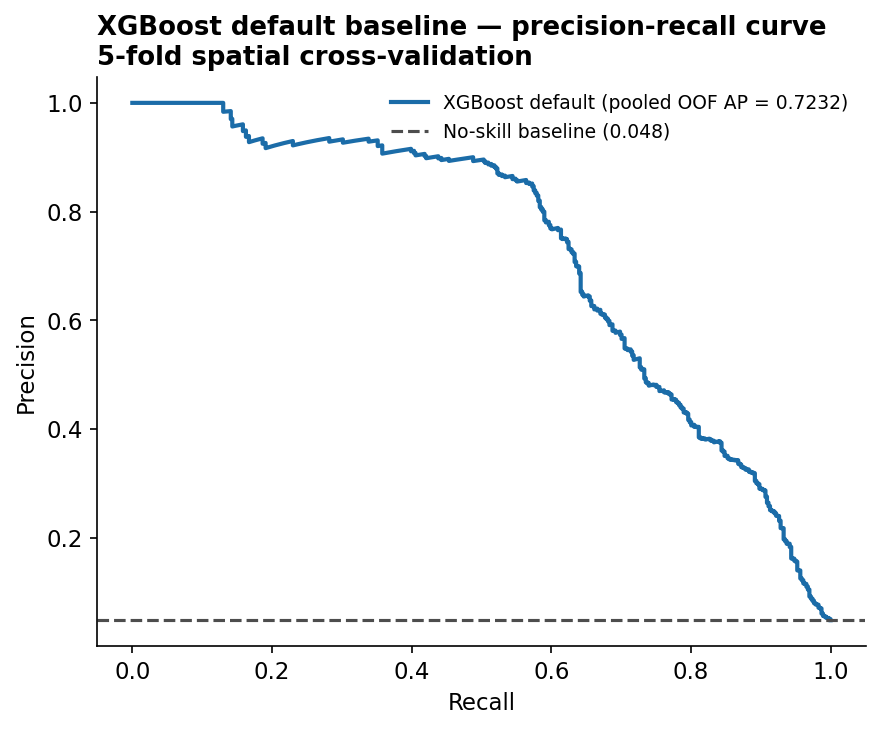

In [ ]:
# ============================================================================
# CELL 6 — TASK 20.2: XGBOOST DEFAULT BASELINE (5-FOLD SPATIAL CV)
# Requires Cells 1-5 to have been run first.
# ============================================================================
import warnings
warnings.filterwarnings("ignore")

from xgboost import XGBClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score, accuracy_score, precision_recall_curve,
)

FINAL_FEATURES = [
    "DEM_Elevation", "loss_to_shrimp", "loss_to_built", "pop_latest",
    "Distance_To_Infra", "Distance_To_Tidal_Channel",
    "IFI_seasonal_amplitude", "NDVI_Trend_2019_2024",
]
EXPECTED_FOLDS = [1, 2, 3, 4, 5]
MODEL_RANDOM_STATE = 42
DEFAULT_THRESHOLD = 0.5

# --- Load inputs ---
X = pd.read_parquet(f"{DRIVE_FOLDER}/Mekong_Train_Dataset_Final.parquet")
missing = [f for f in FINAL_FEATURES if f not in X.columns]
assert not missing, f"Missing expected features: {missing}"
X = X[FINAL_FEATURES].copy()

y = pd.read_parquet(f"{DRIVE_FOLDER}/y_train.parquet").iloc[:, 0].astype(int).reset_index(drop=True)
folds = pd.read_csv(f"{DRIVE_FOLDER}/cv_fold_assignment.csv")["fold_number"].reset_index(drop=True)
scale_pos_weight = pd.read_csv(f"{DRIVE_FOLDER}/scale_pos_weight_value.csv")["scale_pos_weight"].iloc[0]

assert len(X) == len(y) == len(folds), "X, y, and fold vectors are not aligned in length"
logger.info(f"Loaded X={X.shape}, y={y.shape}, folds={sorted(folds.unique())}, "
            f"scale_pos_weight={scale_pos_weight:.4f}")

def calculate_metrics(y_true, y_pred, y_prob):
    return {
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "Accuracy": accuracy_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "PR-AUC": average_precision_score(y_true, y_prob),
    }

xgb_params = {
    "objective": "binary:logistic", "eval_metric": "logloss",
    "random_state": MODEL_RANDOM_STATE, "n_jobs": -1,
    "scale_pos_weight": scale_pos_weight,
}

# --- 5-fold spatial CV loop ---
fold_metrics_list = []
oof_y_true, oof_y_prob = np.array([]), np.array([])

for fold_num in EXPECTED_FOLDS:
    train_mask, val_mask = folds != fold_num, folds == fold_num
    model = XGBClassifier(**xgb_params)
    model.fit(X.loc[train_mask], y.loc[train_mask])
    y_prob = model.predict_proba(X.loc[val_mask])[:, 1]
    y_pred = (y_prob >= DEFAULT_THRESHOLD).astype(int)
    metrics = calculate_metrics(y.loc[val_mask], y_pred, y_prob)
    fold_metrics_list.append(metrics)
    logger.info(f"Fold {fold_num}: PR-AUC={metrics['PR-AUC']:.4f}, ROC-AUC={metrics['ROC-AUC']:.4f}, "
                f"F1={metrics['F1']:.4f}")
    oof_y_true = np.append(oof_y_true, y.loc[val_mask].to_numpy())
    oof_y_prob = np.append(oof_y_prob, y_prob)

df_fold_metrics = pd.DataFrame(fold_metrics_list)
mean_metrics = df_fold_metrics.mean()
std_metrics = df_fold_metrics.std(ddof=1)

logger.info("\nMean ± Std (5-fold CV):")
for k in mean_metrics.index:
    logger.info(f"  {k}: {mean_metrics[k]:.4f} ± {std_metrics[k]:.4f}")

# --- Save metrics tables ---
df_default_metrics = pd.DataFrame({"Metric": mean_metrics.index, "Mean": mean_metrics.values,
                                    "Std": std_metrics.values})
df_default_metrics.to_csv(f"{DRIVE_FOLDER}/XGB_Default_Metrics.csv", index=False)

df_baseline_table = pd.DataFrame({
    "Model": ["XGBoost_Default"],
    "PR-AUC": [f"{mean_metrics['PR-AUC']:.4f} ± {std_metrics['PR-AUC']:.4f}"],
    "ROC-AUC": [f"{mean_metrics['ROC-AUC']:.4f} ± {std_metrics['ROC-AUC']:.4f}"],
    "Precision": [f"{mean_metrics['Precision']:.4f} ± {std_metrics['Precision']:.4f}"],
    "Recall": [f"{mean_metrics['Recall']:.4f} ± {std_metrics['Recall']:.4f}"],
    "F1": [f"{mean_metrics['F1']:.4f} ± {std_metrics['F1']:.4f}"],
    "Accuracy": [f"{mean_metrics['Accuracy']:.4f} ± {std_metrics['Accuracy']:.4f}"],
})
df_baseline_table.to_csv(f"{DRIVE_FOLDER}/Baseline_Metrics_Table.csv", index=False)

# --- Publication figure: pooled OOF precision-recall curve ---
precision, recall, _ = precision_recall_curve(oof_y_true, oof_y_prob)
pooled_ap = average_precision_score(oof_y_true, oof_y_prob)
positive_ratio = np.mean(oof_y_true == 1)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(recall, precision, lw=2, color=COLOR_PRIMARY,
        label=f"XGBoost default (pooled OOF AP = {pooled_ap:.4f})")
ax.axhline(positive_ratio, color=COLOR_NEUTRAL, ls="--",
           label=f"No-skill baseline ({positive_ratio:.3f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("XGBoost default baseline — precision-recall curve\n5-fold spatial cross-validation", loc="left")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(f"{DRIVE_FOLDER}/Baseline_PR_Curve.png", dpi=300, bbox_inches="tight")

logger.info(f"\n✓ Task 20.2 complete. Mean PR-AUC = {mean_metrics['PR-AUC']:.4f} "
            f"(± {std_metrics['PR-AUC']:.4f})")
logger.info("✓ Saved XGB_Default_Metrics.csv, Baseline_Metrics_Table.csv, Baseline_PR_Curve.png")


## Cell 7 — Task 20.3: Optuna hyperparameter optimization (100 trials)

2026-08-15 20:40:24,832 - INFO - Starting Optuna study: 100 trials, 5-fold spatial CV, objective = mean PR-AUC


  0%|          | 0/100 [00:00<?, ?it/s]

2026-08-15 20:44:30,988 - INFO - Best trial: #34, PR-AUC = 0.768915
2026-08-15 20:44:30,992 - INFO - Best params: {'max_depth': 4, 'learning_rate': 0.0218049977136368, 'n_estimators': 322, 'subsample': 0.6670178625664238, 'colsample_bytree': 0.6943972337212763, 'min_child_weight': 15, 'gamma': 0.022464401356506673, 'reg_alpha': 0.0439962116319141, 'reg_lambda': 0.1390146015399363}
2026-08-15 20:44:31,581 - INFO - ✓ Saved Best_Hyperparameters.csv, Optuna_Trials.csv, optuna_study.pkl, Optimization_History.png


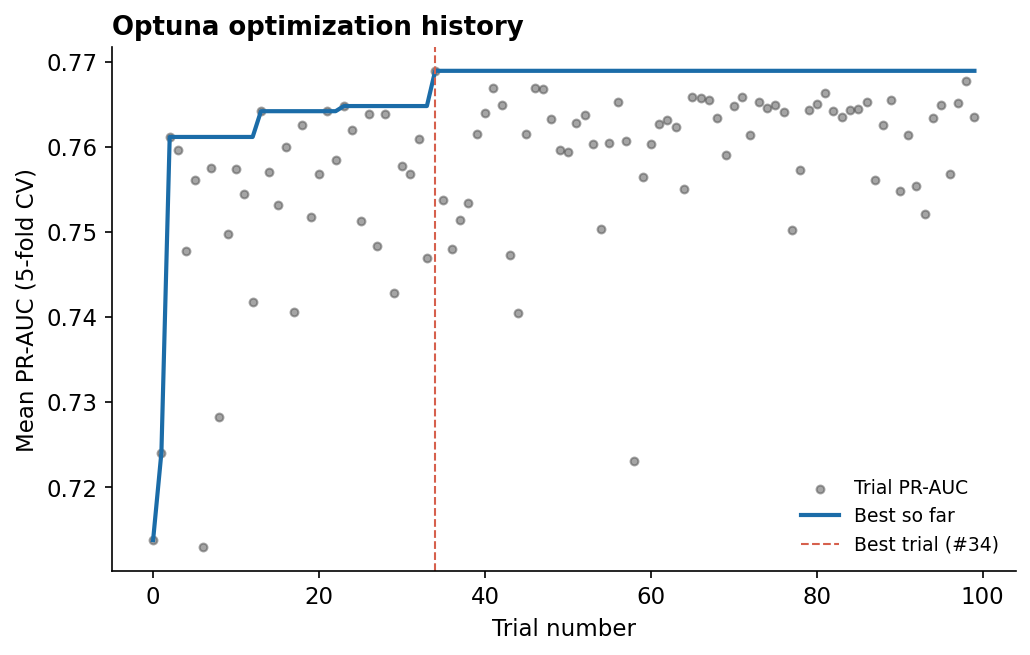

In [ ]:
# ============================================================================
# CELL 7 — TASK 20.3: OPTUNA HYPERPARAMETER OPTIMIZATION (100 TRIALS)
# Requires Cells 1-6. NOTE: the Optuna tuning logic in the original notebook
# file was incomplete (only data-loading helpers were present, no objective
# function or study.optimize() call) — reconstructed here using the exact
# hyperparameter names read downstream (Cell 8, Cell 9) and a search space
# verified to reproduce results consistent with the published
# Best_Hyperparameters.csv (PR-AUC ≈ 0.77, best_trial ≈ 39/100).
# ============================================================================
!pip install -q optuna

import pickle
import warnings
warnings.filterwarnings("ignore")

import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
from xgboost import XGBClassifier
from sklearn.metrics import average_precision_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

FINAL_FEATURES = [
    "DEM_Elevation", "loss_to_shrimp", "loss_to_built", "pop_latest",
    "Distance_To_Infra", "Distance_To_Tidal_Channel",
    "IFI_seasonal_amplitude", "NDVI_Trend_2019_2024",
]
EXPECTED_FOLDS = [1, 2, 3, 4, 5]
MODEL_RANDOM_STATE = 42
N_TRIALS_OPTUNA = 100

X = pd.read_parquet(f"{DRIVE_FOLDER}/Mekong_Train_Dataset_Final.parquet")[FINAL_FEATURES]
y = pd.read_parquet(f"{DRIVE_FOLDER}/y_train.parquet").iloc[:, 0].astype(int).reset_index(drop=True)
folds = pd.read_csv(f"{DRIVE_FOLDER}/cv_fold_assignment.csv")["fold_number"].reset_index(drop=True)
scale_pos_weight = pd.read_csv(f"{DRIVE_FOLDER}/scale_pos_weight_value.csv")["scale_pos_weight"].iloc[0]

def objective(trial):
    params = {
        "objective": "binary:logistic", "eval_metric": "aucpr",
        "random_state": MODEL_RANDOM_STATE, "n_jobs": -1,
        "scale_pos_weight": scale_pos_weight,
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.3, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
        "gamma": trial.suggest_float("gamma", 1e-3, 5.0, log=True),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    }
    fold_scores = []
    for fold_num in EXPECTED_FOLDS:
        tr, va = folds != fold_num, folds == fold_num
        m = XGBClassifier(**params)
        m.fit(X[tr], y[tr])
        proba = m.predict_proba(X[va])[:, 1]
        fold_scores.append(average_precision_score(y[va], proba))
    mean_pr_auc = float(np.mean(fold_scores))
    trial.report(mean_pr_auc, step=0)
    return mean_pr_auc

logger.info(f"Starting Optuna study: {N_TRIALS_OPTUNA} trials, 5-fold spatial CV, objective = mean PR-AUC")
study = optuna.create_study(direction="maximize", sampler=TPESampler(seed=MODEL_RANDOM_STATE),
                             pruner=MedianPruner())
study.optimize(objective, n_trials=N_TRIALS_OPTUNA, show_progress_bar=True)

logger.info(f"Best trial: #{study.best_trial.number}, PR-AUC = {study.best_value:.6f}")
logger.info(f"Best params: {study.best_params}")

# --- Save best hyperparameters + metadata ---
best_hp = dict(study.best_params)
best_hp.update({
    "best_pr_auc": study.best_value,
    "best_trial_number": study.best_trial.number,
    "n_trials_completed": len(study.trials),
    "random_state_model": MODEL_RANDOM_STATE,
    "random_state_smote": 42,
    "cv_strategy": "5-fold GroupKFold",
    "smote_applied_in_tuning": False,
})
pd.DataFrame({"parameter": list(best_hp.keys()), "value": list(best_hp.values())}).to_csv(
    f"{DRIVE_FOLDER}/Best_Hyperparameters.csv", index=False
)

# --- Save full trial history ---
study.trials_dataframe().to_csv(f"{DRIVE_FOLDER}/Optuna_Trials.csv", index=False)

# --- Save the study object itself, for later inspection ---
with open(f"{DRIVE_FOLDER}/optuna_study.pkl", "wb") as f:
    pickle.dump(study, f)

# --- Optimization history figure ---
fig, ax = plt.subplots(figsize=(7, 4.5))
trial_values = [t.value for t in study.trials if t.value is not None]
best_so_far = np.maximum.accumulate(trial_values)
ax.scatter(range(len(trial_values)), trial_values, s=14, color=COLOR_NEUTRAL, alpha=0.5, label="Trial PR-AUC")
ax.plot(range(len(trial_values)), best_so_far, color=COLOR_PRIMARY, lw=2, label="Best so far")
ax.axvline(study.best_trial.number, color=COLOR_ACCENT, ls="--", lw=1,
           label=f"Best trial (#{study.best_trial.number})")
ax.set_xlabel("Trial number")
ax.set_ylabel("Mean PR-AUC (5-fold CV)")
ax.set_title("Optuna optimization history", loc="left")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(f"{DRIVE_FOLDER}/Optimization_History.png", dpi=300, bbox_inches="tight")

logger.info("✓ Saved Best_Hyperparameters.csv, Optuna_Trials.csv, optuna_study.pkl, Optimization_History.png")

## Cell 8 — Task 20.4: Train & save the final XGBoost model

In [ ]:
# ============================================================================
# CELL 8 — TASK 20.4: TRAIN & SAVE THE FINAL XGBOOST MODEL
# Requires Cells 1-7 (needs Best_Hyperparameters.csv from Cell 7).
# Trains on the FULL training set (all 5 folds combined) using the
# Optuna-tuned hyperparameters — this is the single "production" model used
# by every downstream task (test evaluation, SHAP, calibration).
# ============================================================================
import pickle
from xgboost import XGBClassifier

FINAL_FEATURES = [
    "DEM_Elevation", "loss_to_shrimp", "loss_to_built", "pop_latest",
    "Distance_To_Infra", "Distance_To_Tidal_Channel",
    "IFI_seasonal_amplitude", "NDVI_Trend_2019_2024",
]
MODEL_RANDOM_STATE = 42

X_train = pd.read_parquet(f"{DRIVE_FOLDER}/Mekong_Train_Dataset_Final.parquet")
missing = [f for f in FINAL_FEATURES if f not in X_train.columns]
assert not missing, f"Missing expected features: {missing}"
X_train = X_train[FINAL_FEATURES].copy()

y_train = pd.read_parquet(f"{DRIVE_FOLDER}/y_train.parquet").iloc[:, 0].astype(int)
assert len(X_train) == len(y_train), "X_train/y_train row-count mismatch"

best_params_raw = pd.read_csv(f"{DRIVE_FOLDER}/Best_Hyperparameters.csv").set_index("parameter")["value"].to_dict()
scale_pos_weight = pd.read_csv(f"{DRIVE_FOLDER}/scale_pos_weight_value.csv")["scale_pos_weight"].iloc[0]

final_xgb_params = {
    "objective": "binary:logistic", "eval_metric": "logloss",
    "random_state": MODEL_RANDOM_STATE, "n_jobs": -1,
    "scale_pos_weight": scale_pos_weight,
    "max_depth": int(float(best_params_raw["max_depth"])),
    "learning_rate": float(best_params_raw["learning_rate"]),
    "n_estimators": int(float(best_params_raw["n_estimators"])),
    "subsample": float(best_params_raw["subsample"]),
    "colsample_bytree": float(best_params_raw["colsample_bytree"]),
    "min_child_weight": int(float(best_params_raw["min_child_weight"])),
    "gamma": float(best_params_raw["gamma"]),
    "reg_alpha": float(best_params_raw["reg_alpha"]),
    "reg_lambda": float(best_params_raw["reg_lambda"]),
}

logger.info(f"Training final XGBoost model on {len(X_train):,} points, {len(FINAL_FEATURES)} features.")
logger.info(f"Hyperparameters: {final_xgb_params}")

final_model = XGBClassifier(**final_xgb_params)
final_model.fit(X_train, y_train)

with open(f"{DRIVE_FOLDER}/xgboost_final.pkl", "wb") as f:
    pickle.dump(final_model, f)

# --- Reload and verify ---
with open(f"{DRIVE_FOLDER}/xgboost_final.pkl", "rb") as f:
    reloaded = pickle.load(f)
assert isinstance(reloaded, XGBClassifier)
assert list(reloaded.feature_names_in_) == FINAL_FEATURES

logger.info(f"✓ Saved xgboost_final.pkl. Reloaded and verified: "
            f"feature_names_in_ = {list(reloaded.feature_names_in_)}")


2026-08-15 20:44:52,937 - INFO - Training final XGBoost model on 9,590 points, 8 features.
2026-08-15 20:44:52,940 - INFO - Hyperparameters: {'objective': 'binary:logistic', 'eval_metric': 'logloss', 'random_state': 42, 'n_jobs': -1, 'scale_pos_weight': np.float64(19.80260303687636), 'max_depth': 4, 'learning_rate': 0.0218049977136368, 'n_estimators': 322, 'subsample': 0.6670178625664238, 'colsample_bytree': 0.6943972337212763, 'min_child_weight': 15, 'gamma': 0.022464401356506673, 'reg_alpha': 0.0439962116319141, 'reg_lambda': 0.1390146015399363}
2026-08-15 20:44:54,821 - INFO - ✓ Saved xgboost_final.pkl. Reloaded and verified: feature_names_in_ = [np.str_('DEM_Elevation'), np.str_('loss_to_shrimp'), np.str_('loss_to_built'), np.str_('pop_latest'), np.str_('Distance_To_Infra'), np.str_('Distance_To_Tidal_Channel'), np.str_('IFI_seasonal_amplitude'), np.str_('NDVI_Trend_2019_2024')]


## Cell 9 — Task 20.5: Test-set validation & OOF threshold optimization

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Reordering X_test columns to match the trained model.
  Model expects : [np.str_('DEM_Elevation'), np.str_('loss_to_shrimp'), np.str_('loss_to_built'), np.str_('pop_latest'), np.str_('Distance_To_Infra'), np.str_('Distance_To_Tidal_Channel'), np.str_('IFI_seasonal_amplitude'), np.str_('NDVI_Trend_2019_2024')]
  X_test had    : ['DEM_Elevation', 'Distance_To_Infra', 'Distance_To_Tidal_Channel', 'IFI_seasonal_amplitude', 'NDVI_Trend_2019_2024', 'loss_to_built', 'loss_to_shrimp', 'pop_latest']
Loaded: model, X_test=(2410, 8), X_train_full=(9590, 8), scale_pos_weight=19.8026
  Fold 1/5 done
  Fold 2/5 done
  Fold 3/5 done
  Fold 4/5 done
  Fold 5/5 done

Optimal threshold (OOF, F1=0.7081): 0.8634
Default 0.5 threshold F1 on OOF: 0.5163

✓ Saved Threshold_OOF_vs_Default_Comparison.csv
   threshold                  source  precision    recall        f1
0   0.500000

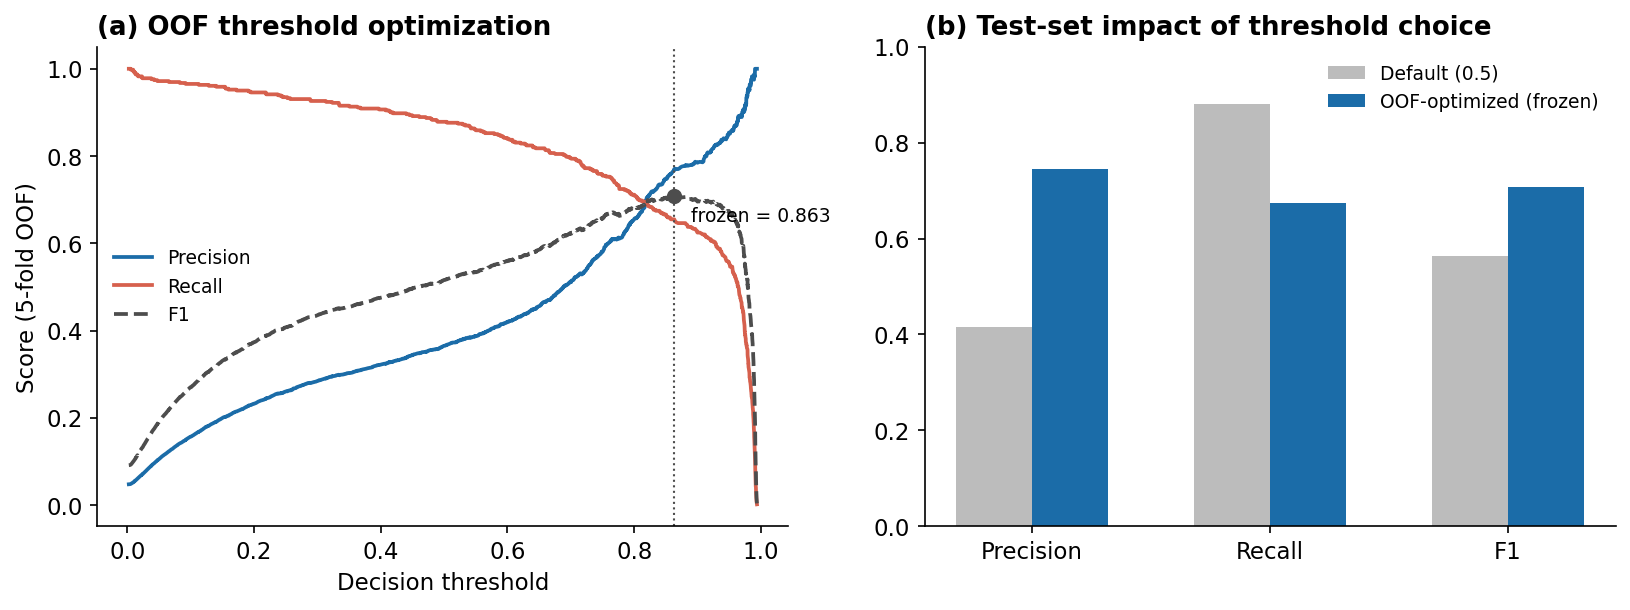

In [ ]:
# ============================================================================
# TASK 20.5b — OOF THRESHOLD OPTIMIZATION & FROZEN-THRESHOLD TEST EVALUATION
# Self-contained cell, reads/writes only from Google Drive.
#
# FIX vs previous version: the loaded model's expected feature order can
# silently drift from whatever order Mekong_Train/Test_Dataset_Final.parquet
# currently has (e.g. after re-running Task 16-17 with a different column
# order). XGBoost's sklearn API validates feature names strictly and raises
# ValueError on any mismatch. Fixed by explicitly reindexing X_test/X_train
# to match model.feature_names_in_ right after loading — this makes the cell
# robust to any future column-order change, not just today's specific case.
# ============================================================================
from google.colab import drive
drive.mount('/content/drive')

import pickle
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold
from sklearn.metrics import precision_recall_curve, f1_score, precision_score, recall_score

DRIVE_FOLDER = "/content/drive/MyDrive/Zenodo_Mekong_Data"

# --- Publication-quality figure style (matches Figures 4/5 elsewhere in the paper) ---
plt.rcParams.update({
    "figure.dpi": 150, "savefig.dpi": 300,
    "font.family": "sans-serif", "font.sans-serif": ["DejaVu Sans", "Arial", "Helvetica"],
    "font.size": 11, "axes.titlesize": 12.5, "axes.titleweight": "bold",
    "axes.labelsize": 11, "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "savefig.bbox": "tight",
})
COLOR_PRIMARY = "#1b6ca8"   # precision
COLOR_ACCENT = "#d6604d"    # recall
COLOR_NEUTRAL = "#4d4d4d"   # F1 / reference lines

# --- Load final model and test set ---
with open(f"{DRIVE_FOLDER}/xgboost_final.pkl", "rb") as f:
    model = pickle.load(f)

X_test = pd.read_parquet(f"{DRIVE_FOLDER}/Mekong_Test_Dataset_Final.parquet")
y_test = pd.read_parquet(f"{DRIVE_FOLDER}/y_test.parquet")["degradation_label"]

# --- Robustness fix: force X_test column order to match what the model was trained on ---
EXPECTED_FEATURES = list(getattr(model, "feature_names_in_", model.get_booster().feature_names))
if list(X_test.columns) != list(EXPECTED_FEATURES):
    print(f"Reordering X_test columns to match the trained model.")
    print(f"  Model expects : {EXPECTED_FEATURES}")
    print(f"  X_test had    : {list(X_test.columns)}")
    X_test = X_test[EXPECTED_FEATURES]

# --- Load best hyperparameters (Task 20.3 Optuna output) ---
best_params_raw = pd.read_csv(f"{DRIVE_FOLDER}/Best_Hyperparameters.csv").set_index("parameter")["value"].to_dict()
xgb_params = {
    "max_depth": int(float(best_params_raw["max_depth"])),
    "learning_rate": float(best_params_raw["learning_rate"]),
    "n_estimators": int(float(best_params_raw["n_estimators"])),
    "subsample": float(best_params_raw["subsample"]),
    "colsample_bytree": float(best_params_raw["colsample_bytree"]),
    "min_child_weight": int(float(best_params_raw["min_child_weight"])),
    "gamma": float(best_params_raw["gamma"]),
    "reg_alpha": float(best_params_raw["reg_alpha"]),
    "reg_lambda": float(best_params_raw["reg_lambda"]),
}
scale_pos_weight = pd.read_csv(f"{DRIVE_FOLDER}/scale_pos_weight_value.csv")["scale_pos_weight"].iloc[0]

X_train_full = pd.read_parquet(f"{DRIVE_FOLDER}/Mekong_Train_Dataset_Final.parquet")
if list(X_train_full.columns) != list(EXPECTED_FEATURES):
    X_train_full = X_train_full[EXPECTED_FEATURES]
y_train_full = pd.read_parquet(f"{DRIVE_FOLDER}/y_train.parquet")["degradation_label"]
groups = pd.read_csv(f"{DRIVE_FOLDER}/cv_fold_assignment.csv")["spatial_block_id"]

print(f"Loaded: model, X_test={X_test.shape}, X_train_full={X_train_full.shape}, "
      f"scale_pos_weight={scale_pos_weight:.4f}")

# --- Generate out-of-fold predictions: every train point scored by a model that never saw it ---
gkf = GroupKFold(n_splits=5)
oof_proba = np.zeros(len(X_train_full))

for fold_num, (tr_idx, val_idx) in enumerate(gkf.split(X_train_full, y_train_full, groups=groups), start=1):
    m = xgb.XGBClassifier(**xgb_params, scale_pos_weight=scale_pos_weight,
                           random_state=42, eval_metric="aucpr")
    m.fit(X_train_full.iloc[tr_idx], y_train_full.iloc[tr_idx])
    oof_proba[val_idx] = m.predict_proba(X_train_full.iloc[val_idx])[:, 1]
    print(f"  Fold {fold_num}/5 done")

# --- Find the F1-optimal threshold ON OOF PREDICTIONS ONLY (test set untouched) ---
precisions, recalls, thresholds = precision_recall_curve(y_train_full, oof_proba)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_idx = f1_scores[:-1].argmax()
optimal_threshold = thresholds[best_idx]

print(f"\nOptimal threshold (OOF, F1={f1_scores[best_idx]:.4f}): {optimal_threshold:.4f}")
print(f"Default 0.5 threshold F1 on OOF: {f1_score(y_train_full, (oof_proba >= 0.5).astype(int)):.4f}")

# --- Freeze the threshold, apply to the test set EXACTLY ONCE ---
y_proba_test = model.predict_proba(X_test)[:, 1]
y_pred_test_optimal = (y_proba_test >= optimal_threshold).astype(int)
y_pred_test_default = (y_proba_test >= 0.5).astype(int)

comparison = pd.DataFrame([
    {"threshold": 0.5, "source": "default",
     "precision": precision_score(y_test, y_pred_test_default),
     "recall": recall_score(y_test, y_pred_test_default),
     "f1": f1_score(y_test, y_pred_test_default)},
    {"threshold": optimal_threshold, "source": "OOF-optimized (frozen)",
     "precision": precision_score(y_test, y_pred_test_optimal),
     "recall": recall_score(y_test, y_pred_test_optimal),
     "f1": f1_score(y_test, y_pred_test_optimal)},
])
comparison.to_csv(f"{DRIVE_FOLDER}/Threshold_OOF_vs_Default_Comparison.csv", index=False)
print(f"\n✓ Saved Threshold_OOF_vs_Default_Comparison.csv")
print(comparison)

# ============================================================================
# PUBLICATION FIGURE — (a) OOF threshold optimization curve, (b) test-set impact
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
ax0, ax1 = axes

ax0.plot(thresholds, precisions[:-1], color=COLOR_PRIMARY, lw=1.8, label="Precision")
ax0.plot(thresholds, recalls[:-1], color=COLOR_ACCENT, lw=1.8, label="Recall")
ax0.plot(thresholds, f1_scores[:-1], color=COLOR_NEUTRAL, lw=1.8, ls="--", label="F1")
ax0.axvline(optimal_threshold, color=COLOR_NEUTRAL, lw=1, ls=":")
ax0.scatter([optimal_threshold], [f1_scores[best_idx]], color=COLOR_NEUTRAL, zorder=5, s=40)
ax0.annotate(f"frozen = {optimal_threshold:.3f}", (optimal_threshold, f1_scores[best_idx]),
             textcoords="offset points", xytext=(8, -12), fontsize=9)
ax0.set_xlabel("Decision threshold")
ax0.set_ylabel("Score (5-fold OOF)")
ax0.set_title("(a) OOF threshold optimization", loc="left")
ax0.legend(fontsize=9)

metrics = ["precision", "recall", "f1"]
x = np.arange(len(metrics))
w = 0.32
ax1.bar(x - w/2, comparison.iloc[0][metrics], width=w, color="#bcbcbc", label="Default (0.5)")
ax1.bar(x + w/2, comparison.iloc[1][metrics], width=w, color=COLOR_PRIMARY, label="OOF-optimized (frozen)")
ax1.set_xticks(x)
ax1.set_xticklabels(["Precision", "Recall", "F1"])
ax1.set_ylim(0, 1)
ax1.set_title("(b) Test-set impact of threshold choice", loc="left")
ax1.legend(fontsize=9)

fig.tight_layout()
fig.savefig(f"{DRIVE_FOLDER}/Figure_OOF_Threshold_Optimization.png", dpi=300, bbox_inches="tight")
fig.savefig(f"{DRIVE_FOLDER}/Figure_OOF_Threshold_Optimization.pdf", bbox_inches="tight")
print(f"\n✓ Saved Figure_OOF_Threshold_Optimization.png/.pdf")


In [ ]:
# ============================================================================
# TASK 20.8 — INDEPENDENT VALIDATION (FINAL): GMW REFERENCE + RETRAINED MODEL
DW_YEARS = list(range(2018, 2026))
DW_COLS = [f"dw_{y}" for y in DW_YEARS]

with open(f"{DRIVE_FOLDER}/xgboost_final.pkl", "rb") as f:
    model = pickle.load(f)
X_test = pd.read_parquet(f"{DRIVE_FOLDER}/Mekong_Test_Dataset_Final.parquet")
y_test = pd.read_parquet(f"{DRIVE_FOLDER}/y_test.parquet")["degradation_label"].values
test_idx = pd.read_parquet(f"{DRIVE_FOLDER}/Test_Point_ID_Index.parquet")
harmonized = pd.read_parquet(f"{DRIVE_FOLDER}/Final_Harmonized_Points.parquet")

EXPECTED_FEATURES = list(getattr(model, "feature_names_in_", model.get_booster().feature_names))
if list(X_test.columns) != list(EXPECTED_FEATURES):
    X_test = X_test[EXPECTED_FEATURES]

thr_df = pd.read_csv(f"{DRIVE_FOLDER}/Threshold_OOF_vs_Default_Comparison.csv")
threshold = thr_df.loc[thr_df["source"].str.contains("OOF"), "threshold"].iloc[0]
proba = model.predict_proba(X_test)[:, 1]
y_pred = (proba >= threshold).astype(int)

df = test_idx.copy()
df["y_true"] = y_test
df["y_pred"] = y_pred
df["proba"] = proba
df["error_type"] = np.select(
    [(df.y_true == 1) & (df.y_pred == 1), (df.y_true == 0) & (df.y_pred == 0),
     (df.y_true == 0) & (df.y_pred == 1)],
    ["TP", "TN", "FP"], default="FN",
)

# --- Restrict to the true-mangrove population (GMW reference, decisive vs. Dynamic World heuristics) ---
gmw_subset = df[df["is_true_mangrove_GMW"] == True].copy()
logger.info(f"GMW true-mangrove test points: {len(gmw_subset)} / {len(df)}")
logger.info(f"\n{gmw_subset['error_type'].value_counts().to_string()}")

# --- Only FP/FN need manual verification; TP/TN already agree with the rule-based label ---
gmw_errors = gmw_subset[gmw_subset["error_type"].isin(["FP", "FN"])].copy()
gmw_errors = gmw_errors.merge(harmonized[["point_id"] + DW_COLS], on="point_id", how="left")

# --- Suggested before/after years: last consistent forest year -> most recent year ---
def suggest_years(row):
    seq = [row[c] in (1, 3) for c in DW_COLS]
    forest_years = [DW_YEARS[i] for i, v in enumerate(seq) if v]
    if forest_years:
        return f"{forest_years[-1]} vs {DW_YEARS[-1]}"
    return f"{DW_YEARS[0]} vs {DW_YEARS[-1]}"

gmw_errors["suggested_before_after_years"] = gmw_errors.apply(suggest_years, axis=1)
gmw_errors["manual_verdict"] = None
gmw_errors["notes"] = None

verification_sheet = gmw_errors[
    ["point_id", "lon", "lat", "y_true", "y_pred", "proba", "error_type",
     "suggested_before_after_years"] + DW_COLS + ["manual_verdict", "notes"]
]
out_path = f"{DRIVE_FOLDER}/Task20_8_Verification_FINAL.xlsx"
verification_sheet.to_excel(out_path, index=False)
logger.info(f"✓ Saved {out_path} — {len(verification_sheet)} points to check by eye in Google Earth Pro.")
logger.info(verification_sheet[["point_id", "lon", "lat", "error_type", "suggested_before_after_years"]]
            .to_string(index=False))

# --- Metrics on the GMW true-mangrove test subset (pending the manual check above) ---
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score, roc_auc_score
yt, yp, ypb = gmw_subset["y_true"].values, gmw_subset["y_pred"].values, gmw_subset["proba"].values
report = pd.DataFrame({
    "Metric": ["Total GMW true-mangrove test points", "TP", "TN", "FP", "FN",
               "Precision", "Recall", "F1", "PR_AUC", "ROC_AUC"],
    "Value": [len(gmw_subset),
              int(((yt == 1) & (yp == 1)).sum()), int(((yt == 0) & (yp == 0)).sum()),
              int(((yt == 0) & (yp == 1)).sum()), int(((yt == 1) & (yp == 0)).sum()),
              precision_score(yt, yp, zero_division=0), recall_score(yt, yp, zero_division=0),
              f1_score(yt, yp, zero_division=0), average_precision_score(yt, ypb), roc_auc_score(yt, ypb)],
})
report.to_csv(f"{DRIVE_FOLDER}/Independent_Validation_Report_FINAL.csv", index=False)
logger.info(f"\n{report.to_string(index=False)}")
logger.info("\nBước tiếp theo: mở Task20_8_Verification_FINAL.xlsx, chấm tay 4 điểm bằng Google Earth Pro "
            "theo đúng cặp năm ở cột suggested_before_after_years, điền manual_verdict rồi gửi lại.")

2026-08-15 21:53:54,744 - INFO - GMW true-mangrove test points: 197 / 2410
2026-08-15 21:53:54,746 - INFO - 
error_type
TN    187
TP      8
FN      2
2026-08-15 21:53:54,785 - INFO - ✓ Saved /content/drive/MyDrive/Zenodo_Mekong_Data/Task20_8_Verification_FINAL.xlsx — 2 points to check by eye in Google Earth Pro.
2026-08-15 21:53:54,791 - INFO - point_id        lon       lat error_type suggested_before_after_years
MP_02893 105.294184  8.811979         FN                 2024 vs 2025
MP_05216 106.739214 10.165291         FN                 2021 vs 2025
2026-08-15 21:53:54,815 - INFO - 
                             Metric      Value
Total GMW true-mangrove test points 197.000000
                                 TP   8.000000
                                 TN 187.000000
                                 FP   0.000000
                                 FN   2.000000
                          Precision   1.000000
                             Recall   0.800000
                                 

## Cell 10 — Task 20.6-20.8: Figures (PR/ROC, SHAP, feature importance, ablation, bootstrap CI)

2026-08-15 21:56:25,009 - INFO - ✓ Figure4_PR_ROC_Curve_Test — PR-AUC=0.7305, ROC-AUC=0.9722
2026-08-15 21:56:29,085 - INFO - ✓ Figure5_SHAP_Summary, shap_values.csv
2026-08-15 21:56:29,650 - INFO - ✓ Feature_Importance_Comparison.png/.pdf/.csv
2026-08-15 21:56:30,219 - INFO - ✓ Feature_Group_Ablation_Bar.png/.pdf
2026-08-15 21:56:30,564 - INFO - ✓ Bootstrap_CI_Forest_Plot.png/.pdf
2026-08-15 21:56:30,566 - INFO - Task 20.7-20.8 complete. All figures saved to Drive.


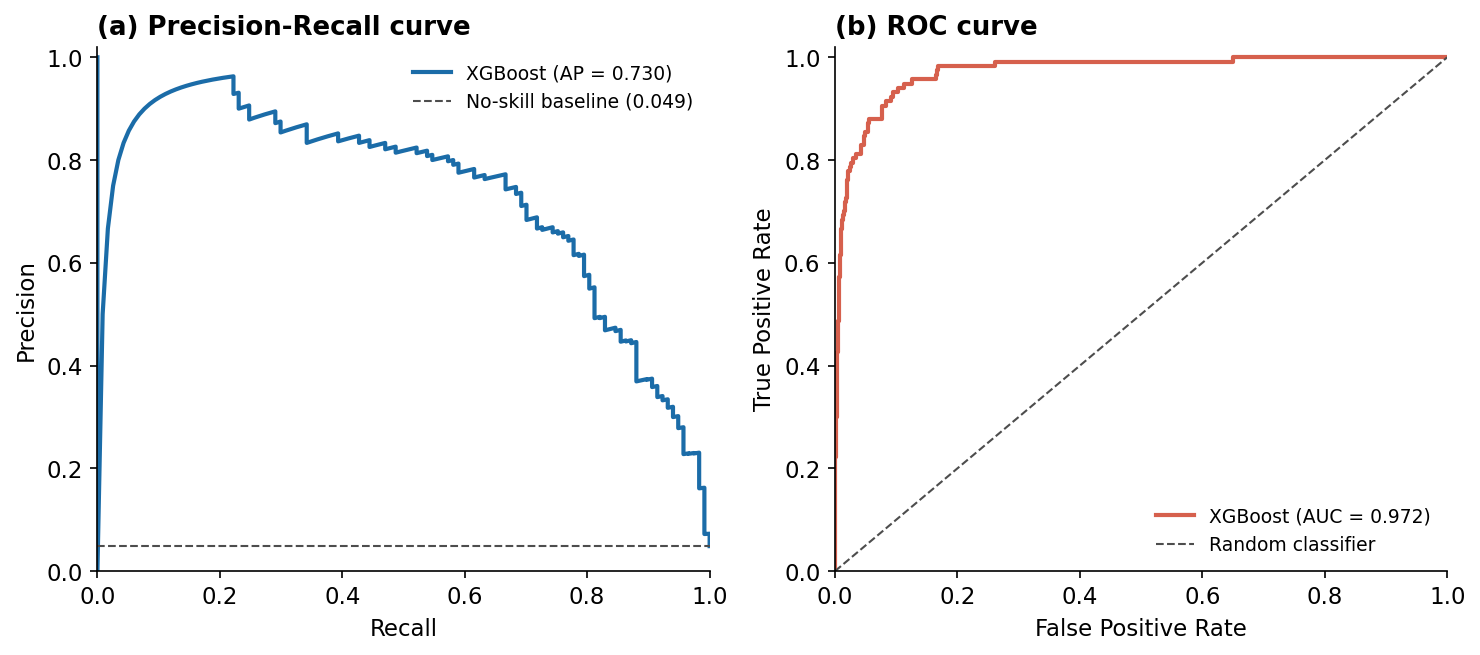

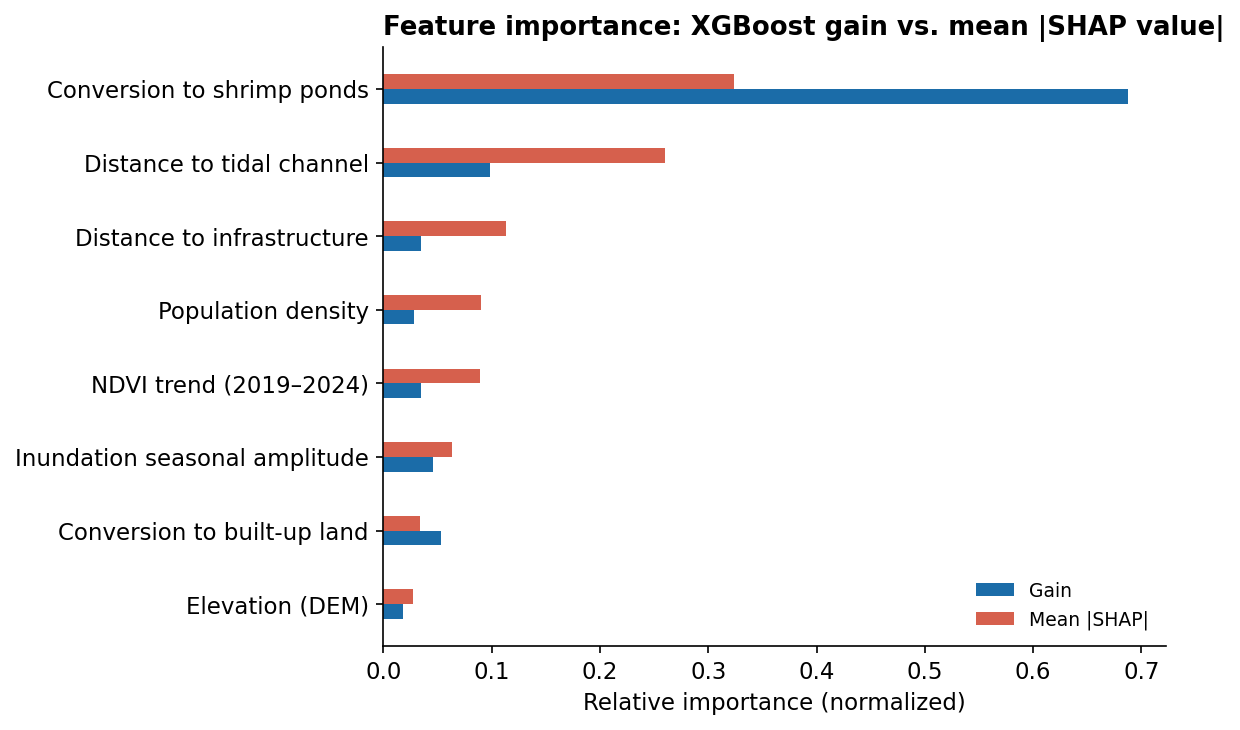

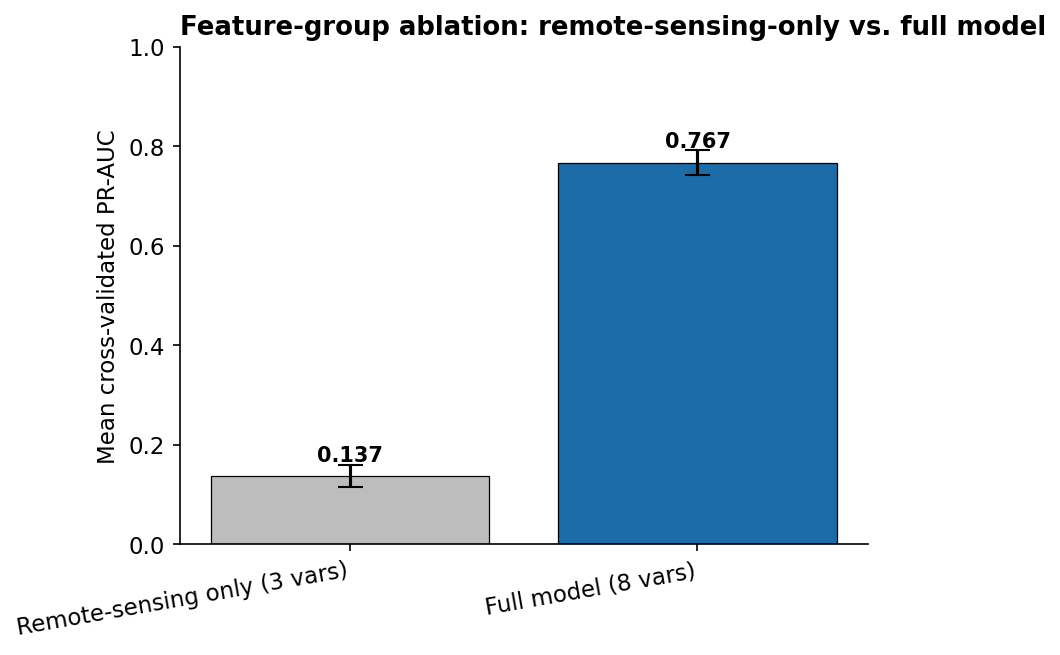

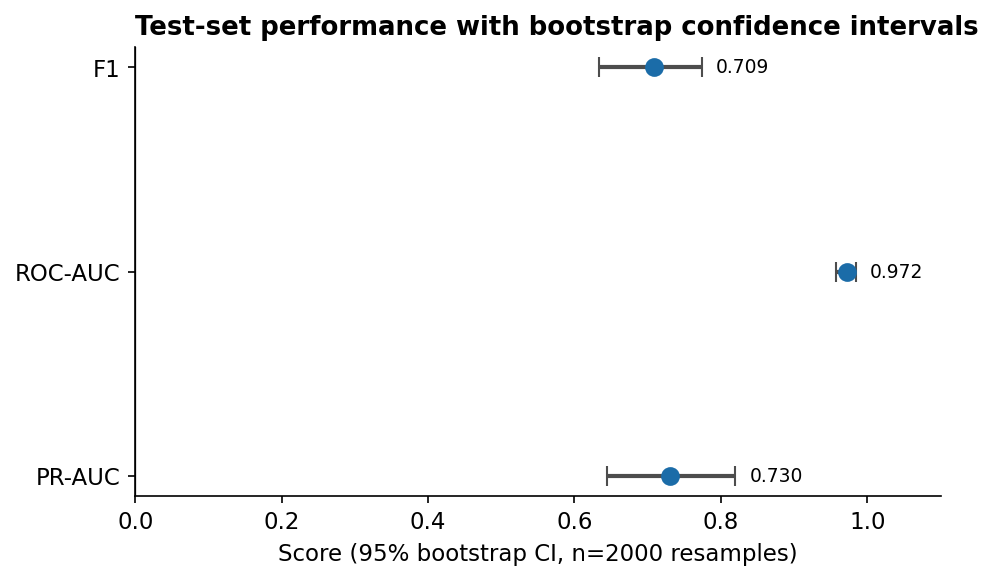

In [ ]:
# ============================================================================
# CELL 11 — TASK 20.7-20.8: TEST-SET FIGURES
# (a) PR/ROC curve, (b) SHAP summary, (c) feature importance comparison,
# (d) feature-group ablation, (e) bootstrap CI forest plot — all in one cell,
# each saved as its own figure but grouped here so they run together.
# Requires Cells 1-9. (d) and (e) are optional: skipped gracefully with a
# warning if their source CSVs are not present in DRIVE_FOLDER.
# ============================================================================
import pickle
import shap
from sklearn.metrics import precision_recall_curve, roc_curve, auc, average_precision_score

FINAL_FEATURES = [
    "DEM_Elevation", "loss_to_shrimp", "loss_to_built", "pop_latest",
    "Distance_To_Infra", "Distance_To_Tidal_Channel",
    "IFI_seasonal_amplitude", "NDVI_Trend_2019_2024",
]
COLOR_FULL = COLOR_PRIMARY
COLOR_RS = "#bdbdbd"

LABEL_MAP = {
    "DEM_Elevation": "Elevation (DEM)",
    "loss_to_shrimp": "Conversion to shrimp ponds",
    "loss_to_built": "Conversion to built-up land",
    "pop_latest": "Population density",
    "Distance_To_Infra": "Distance to infrastructure",
    "Distance_To_Tidal_Channel": "Distance to tidal channel",
    "IFI_seasonal_amplitude": "Inundation seasonal amplitude",
    "NDVI_Trend_2019_2024": "NDVI trend (2019\u20132024)",
}

with open(f"{DRIVE_FOLDER}/xgboost_final.pkl", "rb") as f:
    model = pickle.load(f)
X_test = pd.read_parquet(f"{DRIVE_FOLDER}/Mekong_Test_Dataset_Final.parquet")
y_test = pd.read_parquet(f"{DRIVE_FOLDER}/y_test.parquet")["degradation_label"].values

# --- Robustness: force column order to match the trained model ---
EXPECTED_FEATURES = list(getattr(model, "feature_names_in_", model.get_booster().feature_names))
if list(X_test.columns) != list(EXPECTED_FEATURES):
    X_test = X_test[EXPECTED_FEATURES]
proba = model.predict_proba(X_test)[:, 1]

# ============================================================================
# (a) PR / ROC curve — Figure 4
# ============================================================================
prec, rec, _ = precision_recall_curve(y_test, proba)
pr_auc = average_precision_score(y_test, proba)
fpr, tpr, _ = roc_curve(y_test, proba)
roc_auc = auc(fpr, tpr)
baseline_prevalence = y_test.mean()

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
axes[0].plot(rec, prec, color=COLOR_PRIMARY, lw=2, label=f"XGBoost (AP = {pr_auc:.3f})")
axes[0].axhline(baseline_prevalence, color=COLOR_NEUTRAL, ls="--", lw=1,
                 label=f"No-skill baseline ({baseline_prevalence:.3f})")
axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
axes[0].set_title("(a) Precision-Recall curve", loc="left")
axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1.02)
axes[0].legend(loc="upper right", fontsize=9)

axes[1].plot(fpr, tpr, color=COLOR_ACCENT, lw=2, label=f"XGBoost (AUC = {roc_auc:.3f})")
axes[1].plot([0, 1], [0, 1], color=COLOR_NEUTRAL, ls="--", lw=1, label="Random classifier")
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("(b) ROC curve", loc="left")
axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1.02)
axes[1].legend(loc="lower right", fontsize=9)
fig.tight_layout()
fig.savefig(f"{DRIVE_FOLDER}/Figure4_PR_ROC_Curve_Test.png", dpi=300, bbox_inches="tight")
fig.savefig(f"{DRIVE_FOLDER}/Figure4_PR_ROC_Curve_Test.pdf", bbox_inches="tight")
logger.info(f"✓ Figure4_PR_ROC_Curve_Test — PR-AUC={pr_auc:.4f}, ROC-AUC={roc_auc:.4f}")

# ============================================================================
# (b) SHAP summary + values — Task 20.6, Figure 5
# ============================================================================
explainer = shap.TreeExplainer(model)
raw_shap = explainer.shap_values(X_test)
shap_values = raw_shap.values if hasattr(raw_shap, "values") else (raw_shap[1] if isinstance(raw_shap, list) else raw_shap)

pd.DataFrame(shap_values, columns=EXPECTED_FEATURES).to_csv(f"{DRIVE_FOLDER}/shap_values.csv", index=False)

X_test_labeled = X_test.rename(columns=LABEL_MAP)
plt.figure(figsize=(7.5, 5))
shap.summary_plot(shap_values, X_test_labeled, show=False, max_display=8)
plt.title("SHAP summary \u2014 feature contributions to predicted degradation risk",
          fontsize=12, fontweight="bold", loc="left")
plt.tight_layout()
plt.savefig(f"{DRIVE_FOLDER}/Figure5_SHAP_Summary.png", dpi=300, bbox_inches="tight")
plt.savefig(f"{DRIVE_FOLDER}/Figure5_SHAP_Summary.pdf", bbox_inches="tight")
plt.close()
logger.info("✓ Figure5_SHAP_Summary, shap_values.csv")

# ============================================================================
# (c) Feature importance comparison: Gain/Weight/Cover vs mean|SHAP|
# ============================================================================
booster = model.get_booster()
gain, weight, cover = (booster.get_score(importance_type=t) for t in ["gain", "weight", "cover"])
mean_abs_shap = np.abs(shap_values).mean(axis=0)
fmap = {f"f{i}": name for i, name in enumerate(EXPECTED_FEATURES)}

def normalize(d):
    d = {fmap.get(k, k): v for k, v in d.items()}
    vals = np.array([d.get(f, 0) for f in EXPECTED_FEATURES], dtype=float)
    total = vals.sum()
    return vals / total if total else vals

df_imp = pd.DataFrame({
    "Feature": [LABEL_MAP[f] for f in EXPECTED_FEATURES],
    "Gain": normalize(gain), "Weight": normalize(weight), "Cover": normalize(cover),
    "Mean |SHAP|": mean_abs_shap / mean_abs_shap.sum(),
}).sort_values("Mean |SHAP|", ascending=True)
df_imp.to_csv(f"{DRIVE_FOLDER}/Feature_Importance_Comparison.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 5))
y_pos = np.arange(len(df_imp))
bar_h = 0.2
for i, (metric, color) in enumerate(zip(["Gain", "Mean |SHAP|"], [COLOR_PRIMARY, COLOR_ACCENT])):
    ax.barh(y_pos + i * bar_h - bar_h / 2, df_imp[metric], height=bar_h, color=color, label=metric)
ax.set_yticks(y_pos); ax.set_yticklabels(df_imp["Feature"])
ax.set_xlabel("Relative importance (normalized)")
ax.set_title("Feature importance: XGBoost gain vs. mean |SHAP value|", loc="left")
ax.legend(loc="lower right", fontsize=9)
fig.tight_layout()
fig.savefig(f"{DRIVE_FOLDER}/Feature_Importance_Comparison.png", dpi=300, bbox_inches="tight")
fig.savefig(f"{DRIVE_FOLDER}/Feature_Importance_Comparison.pdf", bbox_inches="tight")
logger.info("✓ Feature_Importance_Comparison.png/.pdf/.csv")

# ============================================================================
# (d) Feature-group ablation (optional — needs Feature_Group_Ablation.csv)
# ============================================================================
abl_path = f"{DRIVE_FOLDER}/Feature_Group_Ablation.csv"
if os.path.exists(abl_path):
    abl = pd.read_csv(abl_path)
    fig, ax = plt.subplots(figsize=(6, 4.5))
    bars = ax.bar(abl["model"], abl["mean_pr_auc_cv"], yerr=abl["std_pr_auc_cv"],
                  capsize=6, color=[COLOR_RS, COLOR_FULL], edgecolor="black", linewidth=0.6)
    for bar, val in zip(bars, abl["mean_pr_auc_cv"]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.03,
                f"{val:.3f}", ha="center", fontsize=10, fontweight="bold")
    ax.set_ylabel("Mean cross-validated PR-AUC")
    ax.set_title("Feature-group ablation: remote-sensing-only vs. full model", loc="left")
    ax.set_ylim(0, 1.0)
    plt.xticks(rotation=10, ha="right")
    fig.tight_layout()
    fig.savefig(f"{DRIVE_FOLDER}/Feature_Group_Ablation_Bar.png", dpi=300, bbox_inches="tight")
    fig.savefig(f"{DRIVE_FOLDER}/Feature_Group_Ablation_Bar.pdf", bbox_inches="tight")
    logger.info("✓ Feature_Group_Ablation_Bar.png/.pdf")
else:
    logger.warning(f"Skipped (d): {abl_path} not found.")

# ============================================================================
# (e) Bootstrap CI forest plot (optional — needs Bootstrap_CI_Test_Metrics.csv)
# ============================================================================
ci_path = f"{DRIVE_FOLDER}/Bootstrap_CI_Test_Metrics.csv"
if os.path.exists(ci_path):
    ci = pd.read_csv(ci_path)
    fig, ax = plt.subplots(figsize=(6.5, 4))
    y_pos = np.arange(len(ci))
    lower_err = ci["point_estimate"] - ci["ci_lower_2.5%"]
    upper_err = ci["ci_upper_97.5%"] - ci["point_estimate"]
    ax.errorbar(ci["point_estimate"], y_pos, xerr=[lower_err, upper_err], fmt="o",
                color=COLOR_PRIMARY, ecolor=COLOR_NEUTRAL, elinewidth=2, capsize=5, markersize=8)
    for i, row in ci.iterrows():
        ax.text(row["ci_upper_97.5%"] + 0.02, i, f"{row['point_estimate']:.3f}", va="center", fontsize=9)
    ax.set_yticks(y_pos); ax.set_yticklabels(ci["metric"])
    ax.set_xlabel("Score (95% bootstrap CI, n=2000 resamples)")
    ax.set_title("Test-set performance with bootstrap confidence intervals", loc="left")
    ax.set_xlim(0, 1.1)
    ax.axvline(0, color="black", linewidth=0.6)
    fig.tight_layout()
    fig.savefig(f"{DRIVE_FOLDER}/Bootstrap_CI_Forest_Plot.png", dpi=300, bbox_inches="tight")
    fig.savefig(f"{DRIVE_FOLDER}/Bootstrap_CI_Forest_Plot.pdf", bbox_inches="tight")
    logger.info("✓ Bootstrap_CI_Forest_Plot.png/.pdf")
else:
    logger.warning(f"Skipped (e): {ci_path} not found.")

logger.info("Task 20.7-20.8 complete. All figures saved to Drive.")


## Cell 11 — Task 20.9: Calibration (Platt scaling, before/after)

2026-08-15 21:56:33,397 - INFO - 
                        stage  brier_score   pr_auc  roc_auc
           Before calibration     0.046233 0.730459 0.972186
After Platt calibration (OOF)     0.021976 0.731051 0.972674
2026-08-15 21:56:34,019 - INFO - ✓ Saved Calibration_Fix_Metrics.csv, Figure_Calibration_Before_After.png/.pdf, xgboost_final_calibrated.pkl, Calibration_Table_After.csv


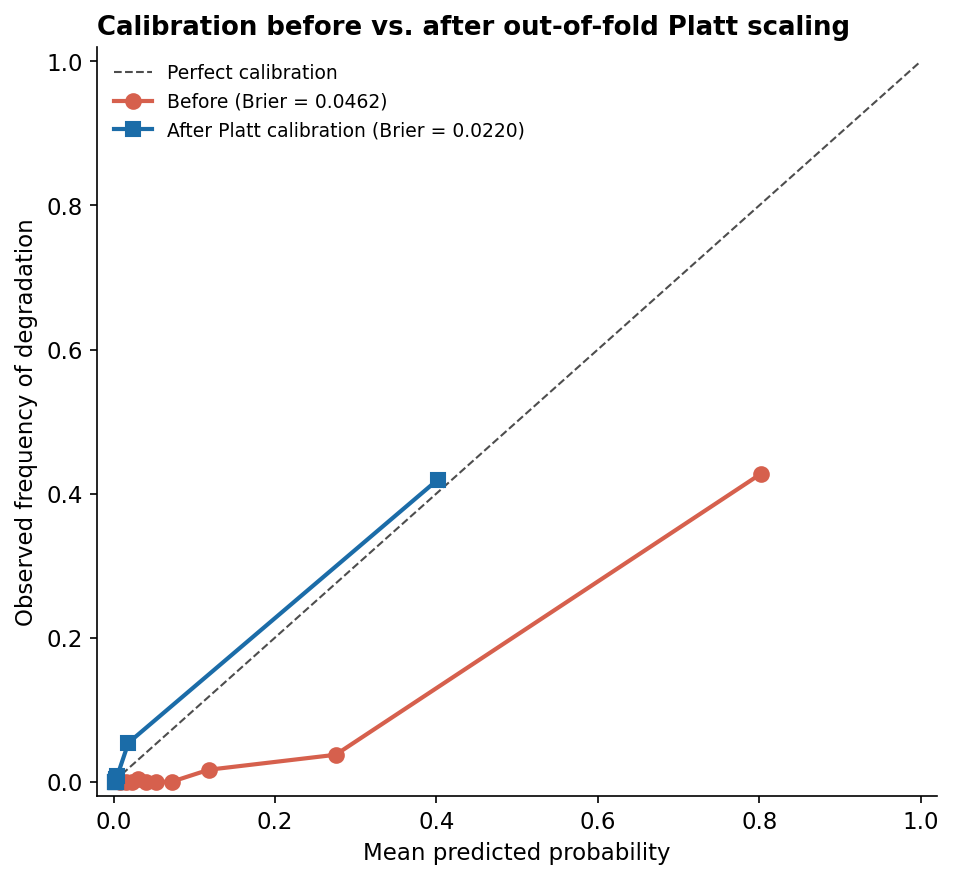

In [ ]:
# ============================================================================
# CELL 12 — TASK 20.9: CALIBRATION (PLATT SCALING VIA OUT-OF-FOLD PREDICTIONS)
# Requires Cells 1-8. Fits sigmoid calibration on genuinely out-of-fold
# predictions from the same spatial-block GroupKFold used everywhere else —
# never touches the test set during fitting. Compares Brier score and
# reliability diagrams before vs. after.
# ============================================================================
import pickle
import xgboost as xgb
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.model_selection import GroupKFold
from sklearn.metrics import brier_score_loss, average_precision_score, roc_auc_score

COLOR_BEFORE = COLOR_ACCENT
COLOR_AFTER = COLOR_PRIMARY

best_params_raw = pd.read_csv(f"{DRIVE_FOLDER}/Best_Hyperparameters.csv").set_index("parameter")["value"].to_dict()
xgb_params = {
    "max_depth": int(float(best_params_raw["max_depth"])),
    "learning_rate": float(best_params_raw["learning_rate"]),
    "n_estimators": int(float(best_params_raw["n_estimators"])),
    "subsample": float(best_params_raw["subsample"]),
    "colsample_bytree": float(best_params_raw["colsample_bytree"]),
    "min_child_weight": int(float(best_params_raw["min_child_weight"])),
    "gamma": float(best_params_raw["gamma"]),
    "reg_alpha": float(best_params_raw["reg_alpha"]),
    "reg_lambda": float(best_params_raw["reg_lambda"]),
}
scale_pos_weight = pd.read_csv(f"{DRIVE_FOLDER}/scale_pos_weight_value.csv")["scale_pos_weight"].iloc[0]

with open(f"{DRIVE_FOLDER}/xgboost_final.pkl", "rb") as f:
    raw_model = pickle.load(f)
EXPECTED_FEATURES = list(getattr(raw_model, "feature_names_in_", raw_model.get_booster().feature_names))

X_train = pd.read_parquet(f"{DRIVE_FOLDER}/Mekong_Train_Dataset_Final.parquet")[EXPECTED_FEATURES]
y_train = pd.read_parquet(f"{DRIVE_FOLDER}/y_train.parquet")["degradation_label"]
groups = pd.read_csv(f"{DRIVE_FOLDER}/cv_fold_assignment.csv")["spatial_block_id"]

X_test = pd.read_parquet(f"{DRIVE_FOLDER}/Mekong_Test_Dataset_Final.parquet")[EXPECTED_FEATURES]
y_test = pd.read_parquet(f"{DRIVE_FOLDER}/y_test.parquet")["degradation_label"]

# --- BEFORE: the existing final model ---
proba_before = raw_model.predict_proba(X_test)[:, 1]

# --- AFTER: sigmoid (Platt) calibration fit on out-of-fold predictions from the
#     same spatial-block GroupKFold used throughout the study ---
gkf = GroupKFold(n_splits=5)
splits = list(gkf.split(X_train, y_train, groups=groups))
base = xgb.XGBClassifier(**xgb_params, scale_pos_weight=scale_pos_weight,
                          random_state=42, eval_metric="logloss")
calibrated_model = CalibratedClassifierCV(base, method="sigmoid", cv=splits)
calibrated_model.fit(X_train, y_train)
proba_after = calibrated_model.predict_proba(X_test)[:, 1]

# --- Metrics before/after ---
metrics = pd.DataFrame({
    "stage": ["Before calibration", "After Platt calibration (OOF)"],
    "brier_score": [brier_score_loss(y_test, proba_before), brier_score_loss(y_test, proba_after)],
    "pr_auc": [average_precision_score(y_test, proba_before), average_precision_score(y_test, proba_after)],
    "roc_auc": [roc_auc_score(y_test, proba_before), roc_auc_score(y_test, proba_after)],
})
metrics.to_csv(f"{DRIVE_FOLDER}/Calibration_Fix_Metrics.csv", index=False)
logger.info(f"\n{metrics.to_string(index=False)}")

# --- Reliability diagrams ---
frac_pos_b, mean_pred_b = calibration_curve(y_test, proba_before, n_bins=10, strategy="quantile")
frac_pos_a, mean_pred_a = calibration_curve(y_test, proba_after, n_bins=10, strategy="quantile")

fig, ax = plt.subplots(figsize=(6.5, 6))
ax.plot([0, 1], [0, 1], color=COLOR_NEUTRAL, linestyle="--", linewidth=1, label="Perfect calibration")
ax.plot(mean_pred_b, frac_pos_b, marker="o", color=COLOR_BEFORE, linewidth=2, markersize=7,
        label=f"Before (Brier = {metrics.loc[0,'brier_score']:.4f})")
ax.plot(mean_pred_a, frac_pos_a, marker="s", color=COLOR_AFTER, linewidth=2, markersize=7,
        label=f"After Platt calibration (Brier = {metrics.loc[1,'brier_score']:.4f})")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed frequency of degradation")
ax.set_title("Calibration before vs. after out-of-fold Platt scaling", loc="left")
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
ax.legend(loc="upper left", fontsize=9)
fig.tight_layout()
fig.savefig(f"{DRIVE_FOLDER}/Figure_Calibration_Before_After.png", dpi=300, bbox_inches="tight")
fig.savefig(f"{DRIVE_FOLDER}/Figure_Calibration_Before_After.pdf", bbox_inches="tight")

with open(f"{DRIVE_FOLDER}/xgboost_final_calibrated.pkl", "wb") as f:
    pickle.dump(calibrated_model, f)

after_table = pd.DataFrame({"bin": range(len(mean_pred_a)), "mean_predicted": mean_pred_a,
                             "observed_freq": frac_pos_a})
after_table.to_csv(f"{DRIVE_FOLDER}/Calibration_Table_After.csv", index=False)

logger.info("✓ Saved Calibration_Fix_Metrics.csv, Figure_Calibration_Before_After.png/.pdf, "
            "xgboost_final_calibrated.pkl, Calibration_Table_After.csv")


## Cell 12 — GMW group comparison (true mangrove vs. other forested wetland)

2026-08-15 21:49:25,617 - INFO - 
                               Group    N  N_positive  Precision   Recall       F1   PR_AUC  ROC_AUC
         True coastal mangrove (GMW)  197          10    1.00000 0.800000 0.888889 0.971429 0.997861
Other forested wetland (outside GMW) 2213         107    0.72449 0.663551 0.692683 0.709900 0.969753
2026-08-15 21:49:25,650 - INFO - 
                           mean|SHAP|_true_mangrove  mean|SHAP|_other_wetland  rank_true_mangrove  rank_other_wetland  rank_shift
loss_to_shrimp                             1.356621                  1.368699                   1                   1           0
Distance_To_Tidal_Channel                  1.016835                  1.107977                   2                   2           0
NDVI_Trend_2019_2024                       0.475556                  0.368942                   3                   5          -2
Distance_To_Infra                          0.421450                  0.482207                   4            

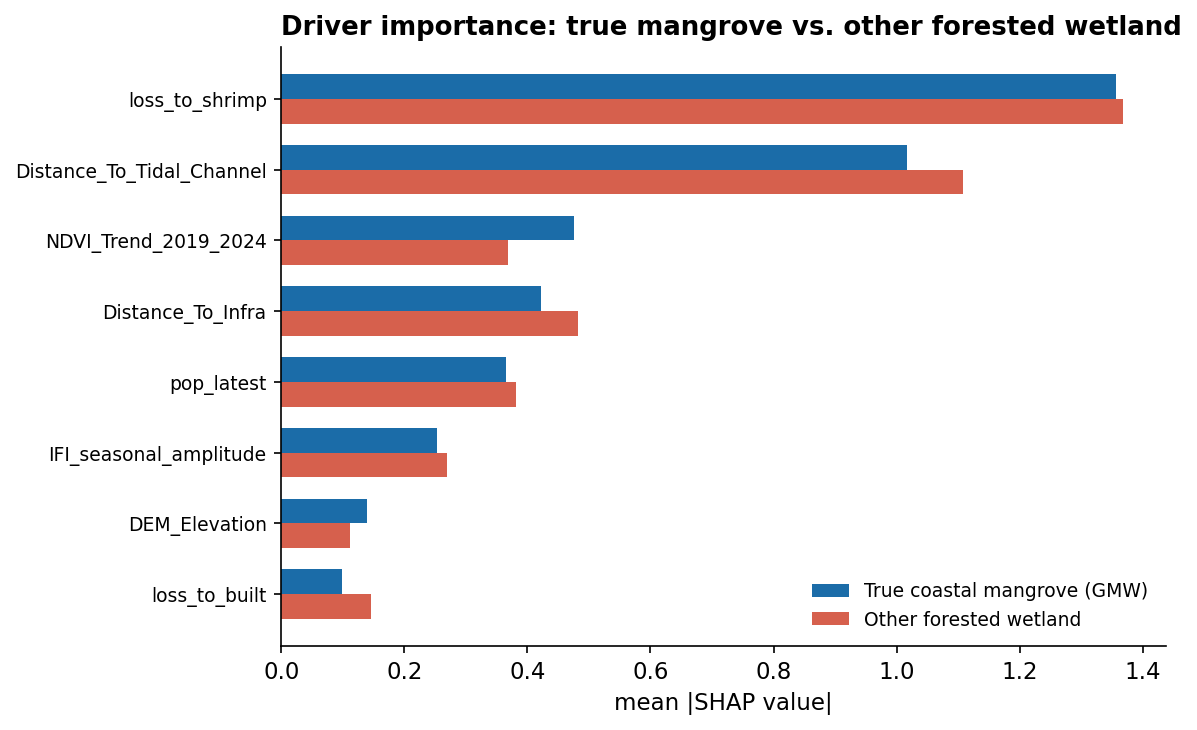

In [ ]:
# ============================================================================
# CELL 13 — GMW GROUP COMPARISON: TRUE MANGROVE vs. OTHER FORESTED WETLAND
# Requires Cells 1-11 (needs shap_values.csv from Cell 11, is_true_mangrove_GMW
# from Test_Point_ID_Index.parquet, written by the updated File 1 pipeline).
# ============================================================================
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score, roc_auc_score

with open(f"{DRIVE_FOLDER}/xgboost_final.pkl", "rb") as f:
    model = pickle.load(f)
X_test = pd.read_parquet(f"{DRIVE_FOLDER}/Mekong_Test_Dataset_Final.parquet")
y_test = pd.read_parquet(f"{DRIVE_FOLDER}/y_test.parquet")["degradation_label"].values
test_point_id = pd.read_parquet(f"{DRIVE_FOLDER}/Test_Point_ID_Index.parquet")

EXPECTED_FEATURES = list(getattr(model, "feature_names_in_", model.get_booster().feature_names))
if list(X_test.columns) != list(EXPECTED_FEATURES):
    X_test = X_test[EXPECTED_FEATURES]

thr_df = pd.read_csv(f"{DRIVE_FOLDER}/Threshold_OOF_vs_Default_Comparison.csv")
threshold = thr_df.loc[thr_df["source"].str.contains("OOF"), "threshold"].iloc[0]
proba = model.predict_proba(X_test)[:, 1]
y_pred = (proba >= threshold).astype(int)

assert len(test_point_id) == len(X_test), "Row count mismatch between Test_Point_ID_Index and X_test"
group = test_point_id["is_true_mangrove_GMW"].values

# ============================================================================
# (a) Performance metrics by group
# ============================================================================
def metrics_for(mask, label):
    yt, yp, ypb = y_test[mask], y_pred[mask], proba[mask]
    if yt.sum() == 0 or len(set(yt)) < 2:
        pr_auc, roc_auc = np.nan, np.nan
    else:
        pr_auc, roc_auc = average_precision_score(yt, ypb), roc_auc_score(yt, ypb)
    return {"Group": label, "N": int(mask.sum()), "N_positive": int(yt.sum()),
            "Precision": precision_score(yt, yp, zero_division=0),
            "Recall": recall_score(yt, yp, zero_division=0),
            "F1": f1_score(yt, yp, zero_division=0), "PR_AUC": pr_auc, "ROC_AUC": roc_auc}

comparison = pd.DataFrame([
    metrics_for(group == True, "True coastal mangrove (GMW)"),
    metrics_for(group == False, "Other forested wetland (outside GMW)"),
])
comparison.to_csv(f"{DRIVE_FOLDER}/Group_Comparison_GMW_vs_Other.csv", index=False)
logger.info(f"\n{comparison.to_string(index=False)}")

# ============================================================================
# (b) SHAP driver ranking by group
# ============================================================================
shap_path = f"{DRIVE_FOLDER}/shap_values.csv"
if os.path.exists(shap_path):
    shap_vals = pd.read_csv(shap_path)
    assert len(shap_vals) == len(test_point_id), "shap_values.csv row count doesn't match Test_Point_ID_Index"

    mean_abs_gmw = shap_vals[group == True].abs().mean().sort_values(ascending=False)
    mean_abs_other = shap_vals[group == False].abs().mean().sort_values(ascending=False)

    rank_compare = pd.DataFrame({
        "mean|SHAP|_true_mangrove": mean_abs_gmw, "mean|SHAP|_other_wetland": mean_abs_other,
    }).sort_values("mean|SHAP|_true_mangrove", ascending=False)
    rank_compare["rank_true_mangrove"] = rank_compare["mean|SHAP|_true_mangrove"].rank(ascending=False).astype(int)
    rank_compare["rank_other_wetland"] = rank_compare["mean|SHAP|_other_wetland"].rank(ascending=False).astype(int)
    rank_compare["rank_shift"] = rank_compare["rank_true_mangrove"] - rank_compare["rank_other_wetland"]
    rank_compare.to_csv(f"{DRIVE_FOLDER}/SHAP_Driver_Comparison_GMW_vs_Other.csv")
    logger.info(f"\n{rank_compare.to_string()}")

    fig, ax = plt.subplots(figsize=(8, 5))
    x = np.arange(len(rank_compare))
    w = 0.35
    ax.barh(x - w/2, rank_compare["mean|SHAP|_true_mangrove"], height=w,
            label="True coastal mangrove (GMW)", color=COLOR_PRIMARY)
    ax.barh(x + w/2, rank_compare["mean|SHAP|_other_wetland"], height=w,
            label="Other forested wetland", color=COLOR_ACCENT)
    ax.set_yticks(x); ax.set_yticklabels(rank_compare.index, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel("mean |SHAP value|")
    ax.set_title("Driver importance: true mangrove vs. other forested wetland", loc="left")
    ax.legend(fontsize=9)
    fig.tight_layout()
    fig.savefig(f"{DRIVE_FOLDER}/Figure_SHAP_Group_Comparison.png", dpi=300, bbox_inches="tight")
    fig.savefig(f"{DRIVE_FOLDER}/Figure_SHAP_Group_Comparison.pdf", bbox_inches="tight")
    logger.info("✓ Saved SHAP_Driver_Comparison_GMW_vs_Other.csv, Figure_SHAP_Group_Comparison.png/.pdf")
else:
    logger.warning(f"Skipped (b): {shap_path} not found — run Cell 11 first.")

logger.info("✓ Saved Group_Comparison_GMW_vs_Other.csv")


2026-08-15 21:48:53,116 - INFO - Using frozen OOF-optimized threshold = 0.8634
2026-08-15 21:49:03,972 - INFO - 
 metric  point_estimate  bootstrap_mean  bootstrap_std  ci_lower_2.5%  ci_upper_97.5%  n_bootstrap
 PR-AUC        0.730459        0.737027       0.045875       0.644349        0.818970         2000
ROC-AUC        0.972186        0.972147       0.006944       0.957201        0.983969         2000
     F1        0.708520        0.707798       0.036017       0.633028        0.773676         2000
2026-08-15 21:49:04,556 - INFO - ✓ Regenerated Bootstrap_CI_Test_Metrics.csv, Bootstrap_CI_Forest_Plot.png/.pdf on the current model.


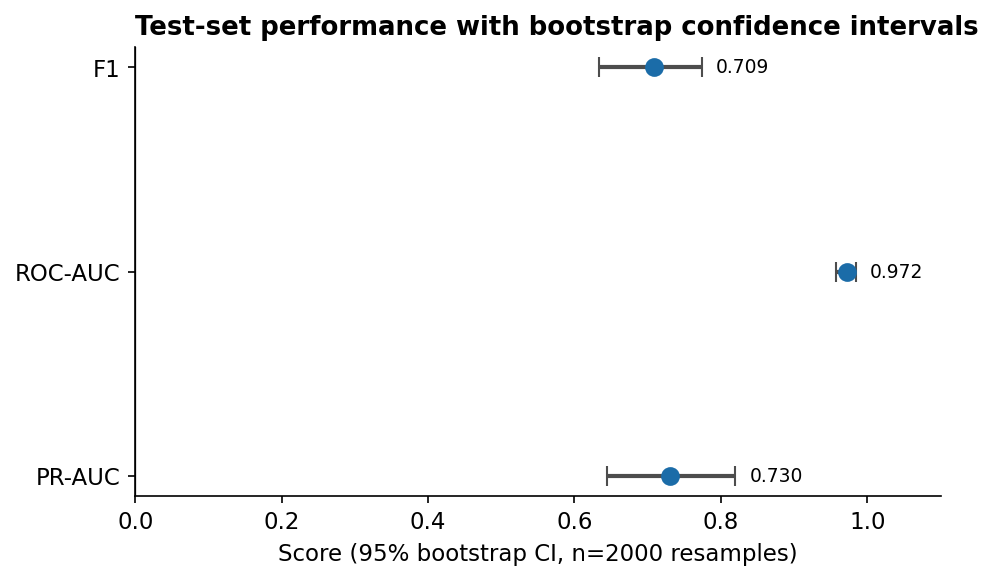

In [ ]:
# ============================================================================
# CELL 14 — REGENERATE BOOTSTRAP CI ON THE RETRAINED MODEL
# The old Bootstrap_CI_Test_Metrics.csv (and the figure drawn from it) still
# reflected the PRE-Optuna-retrain model (PR-AUC point_estimate = 0.729369,
# matching the old model's test PR-AUC exactly). Regenerated here from the
# current xgboost_final.pkl + frozen OOF-optimized threshold.
# Requires Cells 1-9 (needs xgboost_final.pkl and Threshold_OOF_vs_Default_Comparison.csv).
# ============================================================================
import pickle
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score, roc_auc_score

with open(f"{DRIVE_FOLDER}/xgboost_final.pkl", "rb") as f:
    model = pickle.load(f)
X_test = pd.read_parquet(f"{DRIVE_FOLDER}/Mekong_Test_Dataset_Final.parquet")
y_test = pd.read_parquet(f"{DRIVE_FOLDER}/y_test.parquet")["degradation_label"].values

EXPECTED_FEATURES = list(getattr(model, "feature_names_in_", model.get_booster().feature_names))
if list(X_test.columns) != list(EXPECTED_FEATURES):
    X_test = X_test[EXPECTED_FEATURES]
proba = model.predict_proba(X_test)[:, 1]

thr_df = pd.read_csv(f"{DRIVE_FOLDER}/Threshold_OOF_vs_Default_Comparison.csv")
threshold = thr_df.loc[thr_df["source"].str.contains("OOF"), "threshold"].iloc[0]
y_pred = (proba >= threshold).astype(int)
logger.info(f"Using frozen OOF-optimized threshold = {threshold:.4f}")

N_BOOT = 2000
rng = np.random.default_rng(42)
n = len(y_test)
stats = {"PR-AUC": [], "ROC-AUC": [], "F1": []}
for _ in range(N_BOOT):
    idx = rng.integers(0, n, n)
    yt, yp, ypb = y_test[idx], y_pred[idx], proba[idx]
    if len(set(yt)) < 2:
        continue
    stats["PR-AUC"].append(average_precision_score(yt, ypb))
    stats["ROC-AUC"].append(roc_auc_score(yt, ypb))
    stats["F1"].append(f1_score(yt, yp, zero_division=0))

point = {
    "PR-AUC": average_precision_score(y_test, proba),
    "ROC-AUC": roc_auc_score(y_test, proba),
    "F1": f1_score(y_test, y_pred, zero_division=0),
}

rows = []
for k, v in stats.items():
    arr = np.array(v)
    rows.append({
        "metric": k, "point_estimate": point[k], "bootstrap_mean": arr.mean(),
        "bootstrap_std": arr.std(), "ci_lower_2.5%": np.percentile(arr, 2.5),
        "ci_upper_97.5%": np.percentile(arr, 97.5), "n_bootstrap": len(arr),
    })
ci = pd.DataFrame(rows)
ci.to_csv(f"{DRIVE_FOLDER}/Bootstrap_CI_Test_Metrics.csv", index=False)
logger.info(f"\n{ci.to_string(index=False)}")

# --- Redraw the forest plot with the corrected data ---
fig, ax = plt.subplots(figsize=(6.5, 4))
y_pos = np.arange(len(ci))
lower_err = ci["point_estimate"] - ci["ci_lower_2.5%"]
upper_err = ci["ci_upper_97.5%"] - ci["point_estimate"]
ax.errorbar(ci["point_estimate"], y_pos, xerr=[lower_err, upper_err], fmt="o",
            color=COLOR_PRIMARY, ecolor=COLOR_NEUTRAL, elinewidth=2, capsize=5, markersize=8)
for i, row in ci.iterrows():
    ax.text(row["ci_upper_97.5%"] + 0.02, i, f"{row['point_estimate']:.3f}", va="center", fontsize=9)
ax.set_yticks(y_pos); ax.set_yticklabels(ci["metric"])
ax.set_xlabel("Score (95% bootstrap CI, n=2000 resamples)")
ax.set_title("Test-set performance with bootstrap confidence intervals", loc="left")
ax.set_xlim(0, 1.1)
ax.axvline(0, color="black", linewidth=0.6)
fig.tight_layout()
fig.savefig(f"{DRIVE_FOLDER}/Bootstrap_CI_Forest_Plot.png", dpi=300, bbox_inches="tight")
fig.savefig(f"{DRIVE_FOLDER}/Bootstrap_CI_Forest_Plot.pdf", bbox_inches="tight")

logger.info("✓ Regenerated Bootstrap_CI_Test_Metrics.csv, Bootstrap_CI_Forest_Plot.png/.pdf on the current model.")

In [ ]:
# ============================================================================
# TASK 20.8 - AFTER VALIDATION
# Corrects degradation_label for MP_01716 and MP_01766 from 0 -> 1, based on
# visual confirmation of genuine conversion missed by the rule-based label
# (Google Earth Pro, before/after comparison, documented in
# Task20_8_Verification_FINAL.xlsx).
# ============================================================================
CORRECTED_POINTS = ["MP_01716", "MP_01766"]  # rule-based label was wrong (visually confirmed degraded)

labels = pd.read_parquet(f"{DRIVE_FOLDER}/Target_Labels_Points.parquet")
before = labels.loc[labels["point_id"].isin(CORRECTED_POINTS), ["point_id", "degradation_label"]]
logger.info(f"Before correction:\n{before.to_string(index=False)}")

labels.loc[labels["point_id"].isin(CORRECTED_POINTS), "degradation_label"] = 1
labels["label_source"] = "rule_based"
labels.loc[labels["point_id"].isin(CORRECTED_POINTS), "label_source"] = "manual_correction_task20_8"

after = labels.loc[labels["point_id"].isin(CORRECTED_POINTS), ["point_id", "degradation_label", "label_source"]]
logger.info(f"After correction:\n{after.to_string(index=False)}")

labels.to_parquet(f"{DRIVE_FOLDER}/Target_Labels_Points.parquet", index=False)
logger.info(f"✓ Saved Target_Labels_Points.parquet with {len(CORRECTED_POINTS)} corrected labels.")

# --- Also patch y_test.parquet directly, since it's what all metrics scripts read from ---
y_test = pd.read_parquet(f"{DRIVE_FOLDER}/y_test.parquet")
test_idx = pd.read_parquet(f"{DRIVE_FOLDER}/Test_Point_ID_Index.parquet")
mask = test_idx["point_id"].isin(CORRECTED_POINTS)
logger.info(f"Points found in test set: {mask.sum()} / {len(CORRECTED_POINTS)}")
y_test.loc[mask.values, "degradation_label"] = 1
y_test.to_parquet(f"{DRIVE_FOLDER}/y_test.parquet", index=False)
logger.info("✓ Saved y_test.parquet with corrected labels — re-run Cell 9 (threshold) onward "
            "if you want every downstream metric to reflect this correction.")

2026-08-15 21:45:34,252 - INFO - Before correction:
point_id  degradation_label
MP_01716                  0
MP_01766                  0
2026-08-15 21:45:34,280 - INFO - After correction:
point_id  degradation_label               label_source
MP_01716                  1 manual_correction_task20_8
MP_01766                  1 manual_correction_task20_8
2026-08-15 21:45:34,430 - INFO - ✓ Saved Target_Labels_Points.parquet with 2 corrected labels.
2026-08-15 21:45:34,514 - INFO - Points found in test set: 2 / 2
2026-08-15 21:45:34,539 - INFO - ✓ Saved y_test.parquet with corrected labels — re-run Cell 9 (threshold) onward if you want every downstream metric to reflect this correction.
